# Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re
import os
import ast
from datetime import datetime
from collections import defaultdict
from scipy.optimize import curve_fit, fsolve

# Directory containing Ramsey_qubit_* PD/text files.
directory_path = r'Z:\Lab Data\Qudit_Ramsey_raw_data\Line_signal_compensation_data\paper_data'

# Directory containing raw JSONL data files named in the PD/text files.
Z_drive_raw_data = r'Z:\Lab Data\Qudit_Ramsey_raw_data\Raw_data'
# Z_drive_raw_data = r''  # for compatibility with recent data organization
# User input: edit only this transition for a new run.
target_transition = (0, 3, 2)  # (dm, F, mF)

# Fixed frequency: 2*pi over 10 phase points.
def sine_function(t, A, phi, offset):
    return A * np.cos(2 * np.pi / 10 * t + phi) + offset


def combined_decay(t, A, T2_G, T2_L):
    gaussian_decay = np.exp(-(t / T2_G) ** 2)
    lorentzian_decay = np.exp(-t / T2_L)
    return A * gaussian_decay * lorentzian_decay


def parse_filename(filename):
    pattern = (
        r"^Ramsey_qubit_\[\s*(-?\d+)\s*,\s*(-?\d+)\s*,\s*(-?\d+)\s*\]_"
        r"(?:LT)?WaitTime(\d+(?:\.\d+)?)us_comp_(True|False)_"
        r"(\d{8})_(\d{4})(?:_.*)?\.txt$"
    )
    match = re.search(pattern, filename)
    if not match:
        return None

    m = int(match.group(1))
    F = int(match.group(2))
    mF = int(match.group(3))
    wait_time = float(match.group(4))
    comp_flag = match.group(5) == "True"
    date_str = match.group(6) + match.group(7)
    date_time = datetime.strptime(date_str, "%Y%m%d%H%M")
    return m, F, mF, wait_time, comp_flag, date_time


def extract_raw_data_filenames(file_path):
    with open(file_path, "r") as file:
        lines = file.readlines()
    if not lines:
        return []

    raw_data_filenames_line = lines[-1].strip()
    try:
        parsed = ast.literal_eval(raw_data_filenames_line)
        if isinstance(parsed, (list, tuple)):
            return [str(name).strip().strip("'\"") for name in parsed]
    except (SyntaxError, ValueError):
        pass

    return [
        name.strip().strip("'\"")
        for name in raw_data_filenames_line.strip("[]").split(",")
        if name.strip()
    ]


def _raw_path(raw_filename):
    if os.path.isabs(raw_filename):
        return raw_filename
    return os.path.join(Z_drive_raw_data, raw_filename)


def aggregate_runs_by_phase_index(raw_file_runs):
    """
    raw_file_runs is a list of runs for one wait time. Each run is the ordered
    list of raw files for one phase scan. The return value groups files by phase
    index so repeated datetimes at the same wait time are averaged before fitting.
    """
    if len(raw_file_runs) == 0:
        return []

    run_lengths = [len(run) for run in raw_file_runs]
    if len(set(run_lengths)) > 1:
        print(f"Warning: unequal phase-scan lengths for repeated wait time: {run_lengths}")

    n_phase_points = max(run_lengths)
    phase_groups = []
    for phase_index in range(n_phase_points):
        paths_for_phase = []
        for run in raw_file_runs:
            if phase_index < len(run):
                paths_for_phase.append(run[phase_index])
        phase_groups.append(paths_for_phase)
    return phase_groups


def search_files_by_transition_and_comp(directory, target_transition):
    target_transition = tuple(target_transition)
    raw_runs_by_comp_wait = {False: defaultdict(list), True: defaultdict(list)}
    run_records_by_comp_wait = {False: defaultdict(list), True: defaultdict(list)}
    matched_records = []

    for filename in sorted(os.listdir(directory)):
        if not filename.startswith("Ramsey_qubit"):
            continue

        parsed = parse_filename(filename)
        if parsed is None:
            continue

        m, F, mF, wait_time, comp_flag, date_time = parsed
        if (m, F, mF) != target_transition:
            continue

        file_path = os.path.join(directory, filename)
        raw_data_filenames = extract_raw_data_filenames(file_path)
        raw_data_filepaths = [_raw_path(raw_filename) for raw_filename in raw_data_filenames]

        record = {
            "filename": filename,
            "file_path": file_path,
            "transition": (m, F, mF),
            "wait_time_us": wait_time,
            "comp": comp_flag,
            "date_time": date_time,
            "num_phase_points": len(raw_data_filepaths),
            "raw_data_filepaths": raw_data_filepaths,
        }
        raw_runs_by_comp_wait[comp_flag][wait_time].append(raw_data_filepaths)
        run_records_by_comp_wait[comp_flag][wait_time].append(record)
        matched_records.append(record)

    grouped = {}
    for comp_flag in (False, True):
        wait_to_runs = raw_runs_by_comp_wait[comp_flag]
        wait_time_list = sorted(wait_to_runs.keys())
        raw_file_groups_list = []
        raw_file_runs_list = []
        run_records_list = []
        run_count_by_wait_time = {}

        for wait_time in wait_time_list:
            runs = wait_to_runs[wait_time]
            raw_file_runs_list.append(runs)
            run_records_list.append(run_records_by_comp_wait[comp_flag][wait_time])
            raw_file_groups_list.append(aggregate_runs_by_phase_index(runs))
            run_count_by_wait_time[wait_time] = len(runs)

        grouped[comp_flag] = {
            "comp": comp_flag,
            "wait_time_list": wait_time_list,
            "raw_file_groups_list": raw_file_groups_list,
            "raw_file_runs_list": raw_file_runs_list,
            "run_records_list": run_records_list,
            "run_count_by_wait_time": run_count_by_wait_time,
            "matched_files": [r for r in matched_records if r["comp"] == comp_flag],
        }

    return grouped, target_transition, matched_records


ramsey_data_by_comp, final_params, matched_records = search_files_by_transition_and_comp(
    directory_path,
    target_transition,
)

if len(matched_records) == 0:
    raise ValueError(f"No Ramsey_qubit files matched transition {target_transition} in {directory_path}")

m, F, mF = final_params
print(f"Parameters: m={m}, F={F}, mF={mF}")
print(f"Matched {len(matched_records)} PD files across Comp False/True.")

for comp_flag in (False, True):
    group = ramsey_data_by_comp[comp_flag]
    comp_label = f"Comp {comp_flag}"
    print(f"\n{comp_label}: {len(group['matched_files'])} PD files, {len(group['wait_time_list'])} unique wait times")
    for wait_time, phase_groups in zip(group["wait_time_list"], group["raw_file_groups_list"]):
        run_count = group["run_count_by_wait_time"][wait_time]
        files_per_phase = [len(paths) for paths in phase_groups]
        print(
            f"  Wait time: {wait_time} us | runs aggregated: {run_count} | "
            f"phase points: {len(phase_groups)} | raw files/phase: {files_per_phase}"
        )

# Compatibility defaults for older downstream cells: choose Comp True if present,
# otherwise Comp False. The grouped dictionaries above contain both classes.
active_comp_flag = True if len(ramsey_data_by_comp[True]["wait_time_list"]) > 0 else False
wait_time_list = ramsey_data_by_comp[active_comp_flag]["wait_time_list"]
raw_file_paths_list = ramsey_data_by_comp[active_comp_flag]["raw_file_groups_list"]
print(f"\nactive_comp_flag = {active_comp_flag} for compatibility globals")


Parameters: m=0, F=3, mF=2
Matched 381 PD files across Comp False/True.

Comp False: 197 PD files, 35 unique wait times
  Wait time: 0.0 us | runs aggregated: 8 | phase points: 10 | raw files/phase: [8, 8, 8, 8, 8, 8, 8, 8, 8, 8]
  Wait time: 500.0 us | runs aggregated: 8 | phase points: 10 | raw files/phase: [8, 8, 8, 8, 8, 8, 8, 8, 8, 8]
  Wait time: 1000.0 us | runs aggregated: 7 | phase points: 10 | raw files/phase: [7, 7, 7, 7, 7, 7, 7, 7, 7, 7]
  Wait time: 1500.0 us | runs aggregated: 7 | phase points: 10 | raw files/phase: [7, 7, 7, 7, 7, 7, 7, 7, 7, 7]
  Wait time: 2000.0 us | runs aggregated: 7 | phase points: 10 | raw files/phase: [7, 7, 7, 7, 7, 7, 7, 7, 7, 7]
  Wait time: 2500.0 us | runs aggregated: 7 | phase points: 10 | raw files/phase: [7, 7, 7, 7, 7, 7, 7, 7, 7, 7]
  Wait time: 3000.0 us | runs aggregated: 7 | phase points: 10 | raw files/phase: [7, 7, 7, 7, 7, 7, 7, 7, 7, 7]
  Wait time: 3500.0 us | runs aggregated: 8 | phase points: 10 | raw files/phase: [8, 8, 8, 8

In [2]:
import numpy as np
import json
import os


def get_shelving_threshold(counts):
    counts = np.asarray(counts, dtype=float)
    data_sorted = np.sort(counts, axis=None)
    if data_sorted.size == 0:
        return np.nan, data_sorted

    trimmed = data_sorted
    if data_sorted.size > 250:
        candidate = data_sorted[100:-100]
        if candidate.size > 0:
            trimmed = candidate

    if trimmed.size > 1000:
        step = round(trimmed.size / (len(counts) * 0.0250167))
        step = max(step, 1)
        trimmed = trimmed[0:-1:step]

    data_sorted_diff = trimmed[1:-1] - trimmed[0:-2]
    if data_sorted_diff.size == 0:
        threshold = float(np.median(trimmed))
    else:
        data_diff_maxind = int(np.argmax(data_sorted_diff))
        threshold = float(data_sorted_diff[data_diff_maxind] / 2 + trimmed[data_diff_maxind])
    return threshold, trimmed


def _read_raw_counts(file_path):
    arrays = []
    with open(file_path, "r") as file:
        for line in file:
            data = json.loads(line)
            arrays.append(data[0]["0"][:])
    return arrays


def _normalize_raw_data_groups(raw_data_filepaths_or_groups):
    """
    Accepts either the old flat list of raw files or the new grouped format:
      old: [phase0_file, phase1_file, ...]
      new: [[phase0_run0, phase0_run1, ...], [phase1_run0, ...], ...]
    """
    if len(raw_data_filepaths_or_groups) == 0:
        return []

    first = raw_data_filepaths_or_groups[0]
    if isinstance(first, (str, bytes, os.PathLike)):
        return [[path] for path in raw_data_filepaths_or_groups]
    return raw_data_filepaths_or_groups


def _classify_shelving(counts_2d, threshold):
    bool_array = np.asarray(counts_2d) > threshold
    if bool_array.ndim != 2:
        raise ValueError(f"Expected one phase point as a 2D shot/readout array, got shape {bool_array.shape}")

    # Preserve the original notebook's 3-state classification matrix.
    # Recent raw files can have only two readout counts per shot; the third
    # column is still needed to mark shots where readout 0 and 1 are both dark.
    result_width = max(3, bool_array.shape[1])
    result_matrix = np.full((bool_array.shape[0], result_width), False, dtype=bool)
    for row_index in range(bool_array.shape[0]):
        data_bool = bool_array[row_index, :]
        if data_bool.size < 2:
            continue
        if data_bool[0] == False:
            if data_bool[1] == True:
                result_matrix[row_index, 1] = True
            elif data_bool[1] == False:
                result_matrix[row_index, 2] = True
    return result_matrix


def _wilson_interval(num_SD, full_data_array, exp_num):
    full_data_array = np.asarray(full_data_array, dtype=float)
    exp_num = np.asarray(exp_num, dtype=float)
    lower_error = np.full(full_data_array.shape, np.nan, dtype=float)
    upper_error = np.full(full_data_array.shape, np.nan, dtype=float)
    valid = exp_num > 0
    if not np.any(valid):
        return lower_error, upper_error

    p = full_data_array[valid]
    n = exp_num[valid]
    z2 = num_SD ** 2
    denom = 1 + z2 / n
    centre = (p + z2 / (2 * n)) / denom
    radius = np.sqrt((p * (1 - p) * z2) / n + z2 ** 2 / (4 * n ** 2)) / denom
    lower_error[valid] = centre - radius
    upper_error[valid] = centre + radius
    return lower_error, upper_error


def process_raw_data_groups(raw_data_file_groups, ket_index=1, verbose=True):
    """
    Processes one wait time. raw_data_file_groups must be grouped by phase index.
    Repeated datetimes at the same wait time are combined within each phase group
    before producing one ket value per phase point.
    """
    raw_data_file_groups = _normalize_raw_data_groups(raw_data_file_groups)
    if len(raw_data_file_groups) == 0:
        return [], np.array([]), np.array([])

    phase_counts_groups = []
    for phase_group in raw_data_file_groups:
        phase_counts = []
        for file_path in phase_group:
            phase_counts.extend(_read_raw_counts(file_path))
        if len(phase_counts) == 0:
            phase_counts = list(np.full((100, 4), 40))
        phase_counts_groups.append(np.asarray(phase_counts))

    flat_hist_data = np.concatenate([phase_counts.reshape(-1) for phase_counts in phase_counts_groups])
    threshold, _ = get_shelving_threshold(flat_hist_data)

    ket_data = []
    exp_num_list = []
    for phase_counts in phase_counts_groups:
        result_matrix = _classify_shelving(phase_counts, threshold)
        rows_with_any_true = result_matrix.any(axis=1)
        filtered_data = result_matrix[rows_with_any_true]

        if filtered_data.size == 0 or filtered_data.shape[1] <= ket_index:
            ket_data.append(np.nan)
            exp_num_list.append(0)
            continue

        ket_data.append(float(np.mean(filtered_data, axis=0)[ket_index]))
        exp_num_list.append(int(filtered_data.shape[0]))

    if verbose:
        print(f"threshold={threshold:.3f}, exp_num_list={exp_num_list}")
    lower_error, upper_error = _wilson_interval(1, np.array(ket_data), np.array(exp_num_list))
    return ket_data, lower_error, upper_error


def process_all_wait_times_in_lists(wait_time_list, raw_file_groups_list, ket_index=1):
    processed_wait_times = []
    ket_data_list = []
    lower_error_list = []
    upper_error_list = []

    for wait_time, raw_file_groups in sorted(zip(wait_time_list, raw_file_groups_list), key=lambda x: x[0]):
        ket_data, lower_error, upper_error = process_raw_data_groups(raw_file_groups, ket_index=ket_index)
        ket_data_arr = np.array(ket_data, dtype=float)
        final_lower_error = np.abs(ket_data_arr - np.array(lower_error, dtype=float))
        final_upper_error = np.abs(np.array(upper_error, dtype=float) - ket_data_arr)

        processed_wait_times.append(wait_time)
        ket_data_list.append(ket_data)
        lower_error_list.append(final_lower_error)
        upper_error_list.append(final_upper_error)

    return processed_wait_times, ket_data_list, lower_error_list, upper_error_list



def process_individual_runs_for_comp_group(group, ket_index=1):
    individual_runs_by_wait_time = []

    for wait_time, raw_file_runs, run_records in zip(
        group.get("wait_time_list", []),
        group.get("raw_file_runs_list", []),
        group.get("run_records_list", []),
    ):
        run_results = []
        for run_index, raw_file_run in enumerate(raw_file_runs):
            raw_file_groups = [[path] for path in raw_file_run]
            ket_data, lower_error, upper_error = process_raw_data_groups(
                raw_file_groups,
                ket_index=ket_index,
                verbose=False,
            )
            ket_data_arr = np.array(ket_data, dtype=float)
            final_lower_error = np.abs(ket_data_arr - np.array(lower_error, dtype=float))
            final_upper_error = np.abs(np.array(upper_error, dtype=float) - ket_data_arr)

            record = run_records[run_index] if run_index < len(run_records) else {}
            date_time = record.get("date_time")
            label = date_time.strftime("%Y%m%d_%H%M") if date_time is not None else f"run {run_index + 1}"

            run_results.append(
                {
                    "wait_time_us": wait_time,
                    "run_index": run_index,
                    "label": label,
                    "ket_data": ket_data,
                    "lower_error": final_lower_error,
                    "upper_error": final_upper_error,
                    "record": record,
                }
            )
        individual_runs_by_wait_time.append(run_results)

    return individual_runs_by_wait_time

def process_all_comp_groups(ramsey_data_by_comp, ket_index=1):
    processed_data_by_comp = {}
    for comp_flag in (False, True):
        group = ramsey_data_by_comp[comp_flag]
        if len(group["wait_time_list"]) == 0:
            processed_data_by_comp[comp_flag] = {
                "processed_wait_times": [],
                "ket_data_list": [],
                "lower_error_list": [],
                "upper_error_list": [],
                "individual_runs_by_wait_time": [],
            }
            continue

        print(f"\nProcessing Comp {comp_flag}")
        processed_wait_times, ket_data_list, lower_error_list, upper_error_list = process_all_wait_times_in_lists(
            group["wait_time_list"],
            group["raw_file_groups_list"],
            ket_index=ket_index,
        )
        individual_runs_by_wait_time = process_individual_runs_for_comp_group(group, ket_index=ket_index)
        processed_data_by_comp[comp_flag] = {
            "processed_wait_times": processed_wait_times,
            "ket_data_list": ket_data_list,
            "lower_error_list": lower_error_list,
            "upper_error_list": upper_error_list,
            "individual_runs_by_wait_time": individual_runs_by_wait_time,
        }
    return processed_data_by_comp


processed_data_by_comp = process_all_comp_groups(ramsey_data_by_comp, ket_index=1)

active_processed = processed_data_by_comp[active_comp_flag]
wait_time_list = active_processed["processed_wait_times"]
processed_wait_times = active_processed["processed_wait_times"]
ket_data_list = active_processed["ket_data_list"]
lower_error_list = active_processed["lower_error_list"]
upper_error_list = active_processed["upper_error_list"]

print("\nProcessed data summary:")
for comp_flag in (False, True):
    data = processed_data_by_comp[comp_flag]
    print(f"Comp {comp_flag}: {len(data['processed_wait_times'])} wait times")
    for wt, ket_vals in zip(data["processed_wait_times"], data["ket_data_list"]):
        print(f"  Wait Time: {wt} us | phase points: {len(ket_vals)} | ket_data: {ket_vals}")



Processing Comp False
threshold=10.500, exp_num_list=[761, 767, 774, 777, 766, 773, 773, 760, 763, 773]
threshold=11.500, exp_num_list=[681, 684, 679, 675, 671, 675, 678, 675, 673, 676]
threshold=10.000, exp_num_list=[678, 676, 669, 683, 679, 681, 680, 688, 684, 679]
threshold=12.000, exp_num_list=[689, 686, 686, 684, 689, 685, 690, 680, 687, 687]
threshold=11.000, exp_num_list=[693, 688, 688, 688, 683, 690, 687, 690, 685, 687]
threshold=10.500, exp_num_list=[688, 689, 691, 689, 687, 685, 683, 685, 690, 689]
threshold=10.000, exp_num_list=[686, 686, 690, 689, 689, 688, 687, 689, 691, 696]
threshold=10.000, exp_num_list=[792, 792, 794, 788, 791, 790, 782, 787, 792, 786]
threshold=11.500, exp_num_list=[688, 692, 693, 688, 689, 691, 694, 691, 683, 687]
threshold=10.000, exp_num_list=[692, 692, 694, 691, 688, 690, 686, 682, 687, 687]
threshold=10.000, exp_num_list=[686, 688, 695, 693, 694, 693, 688, 691, 687, 687]
threshold=10.500, exp_num_list=[591, 589, 590, 591, 587, 592, 591, 589, 592


Fitting phase scans for Comp False


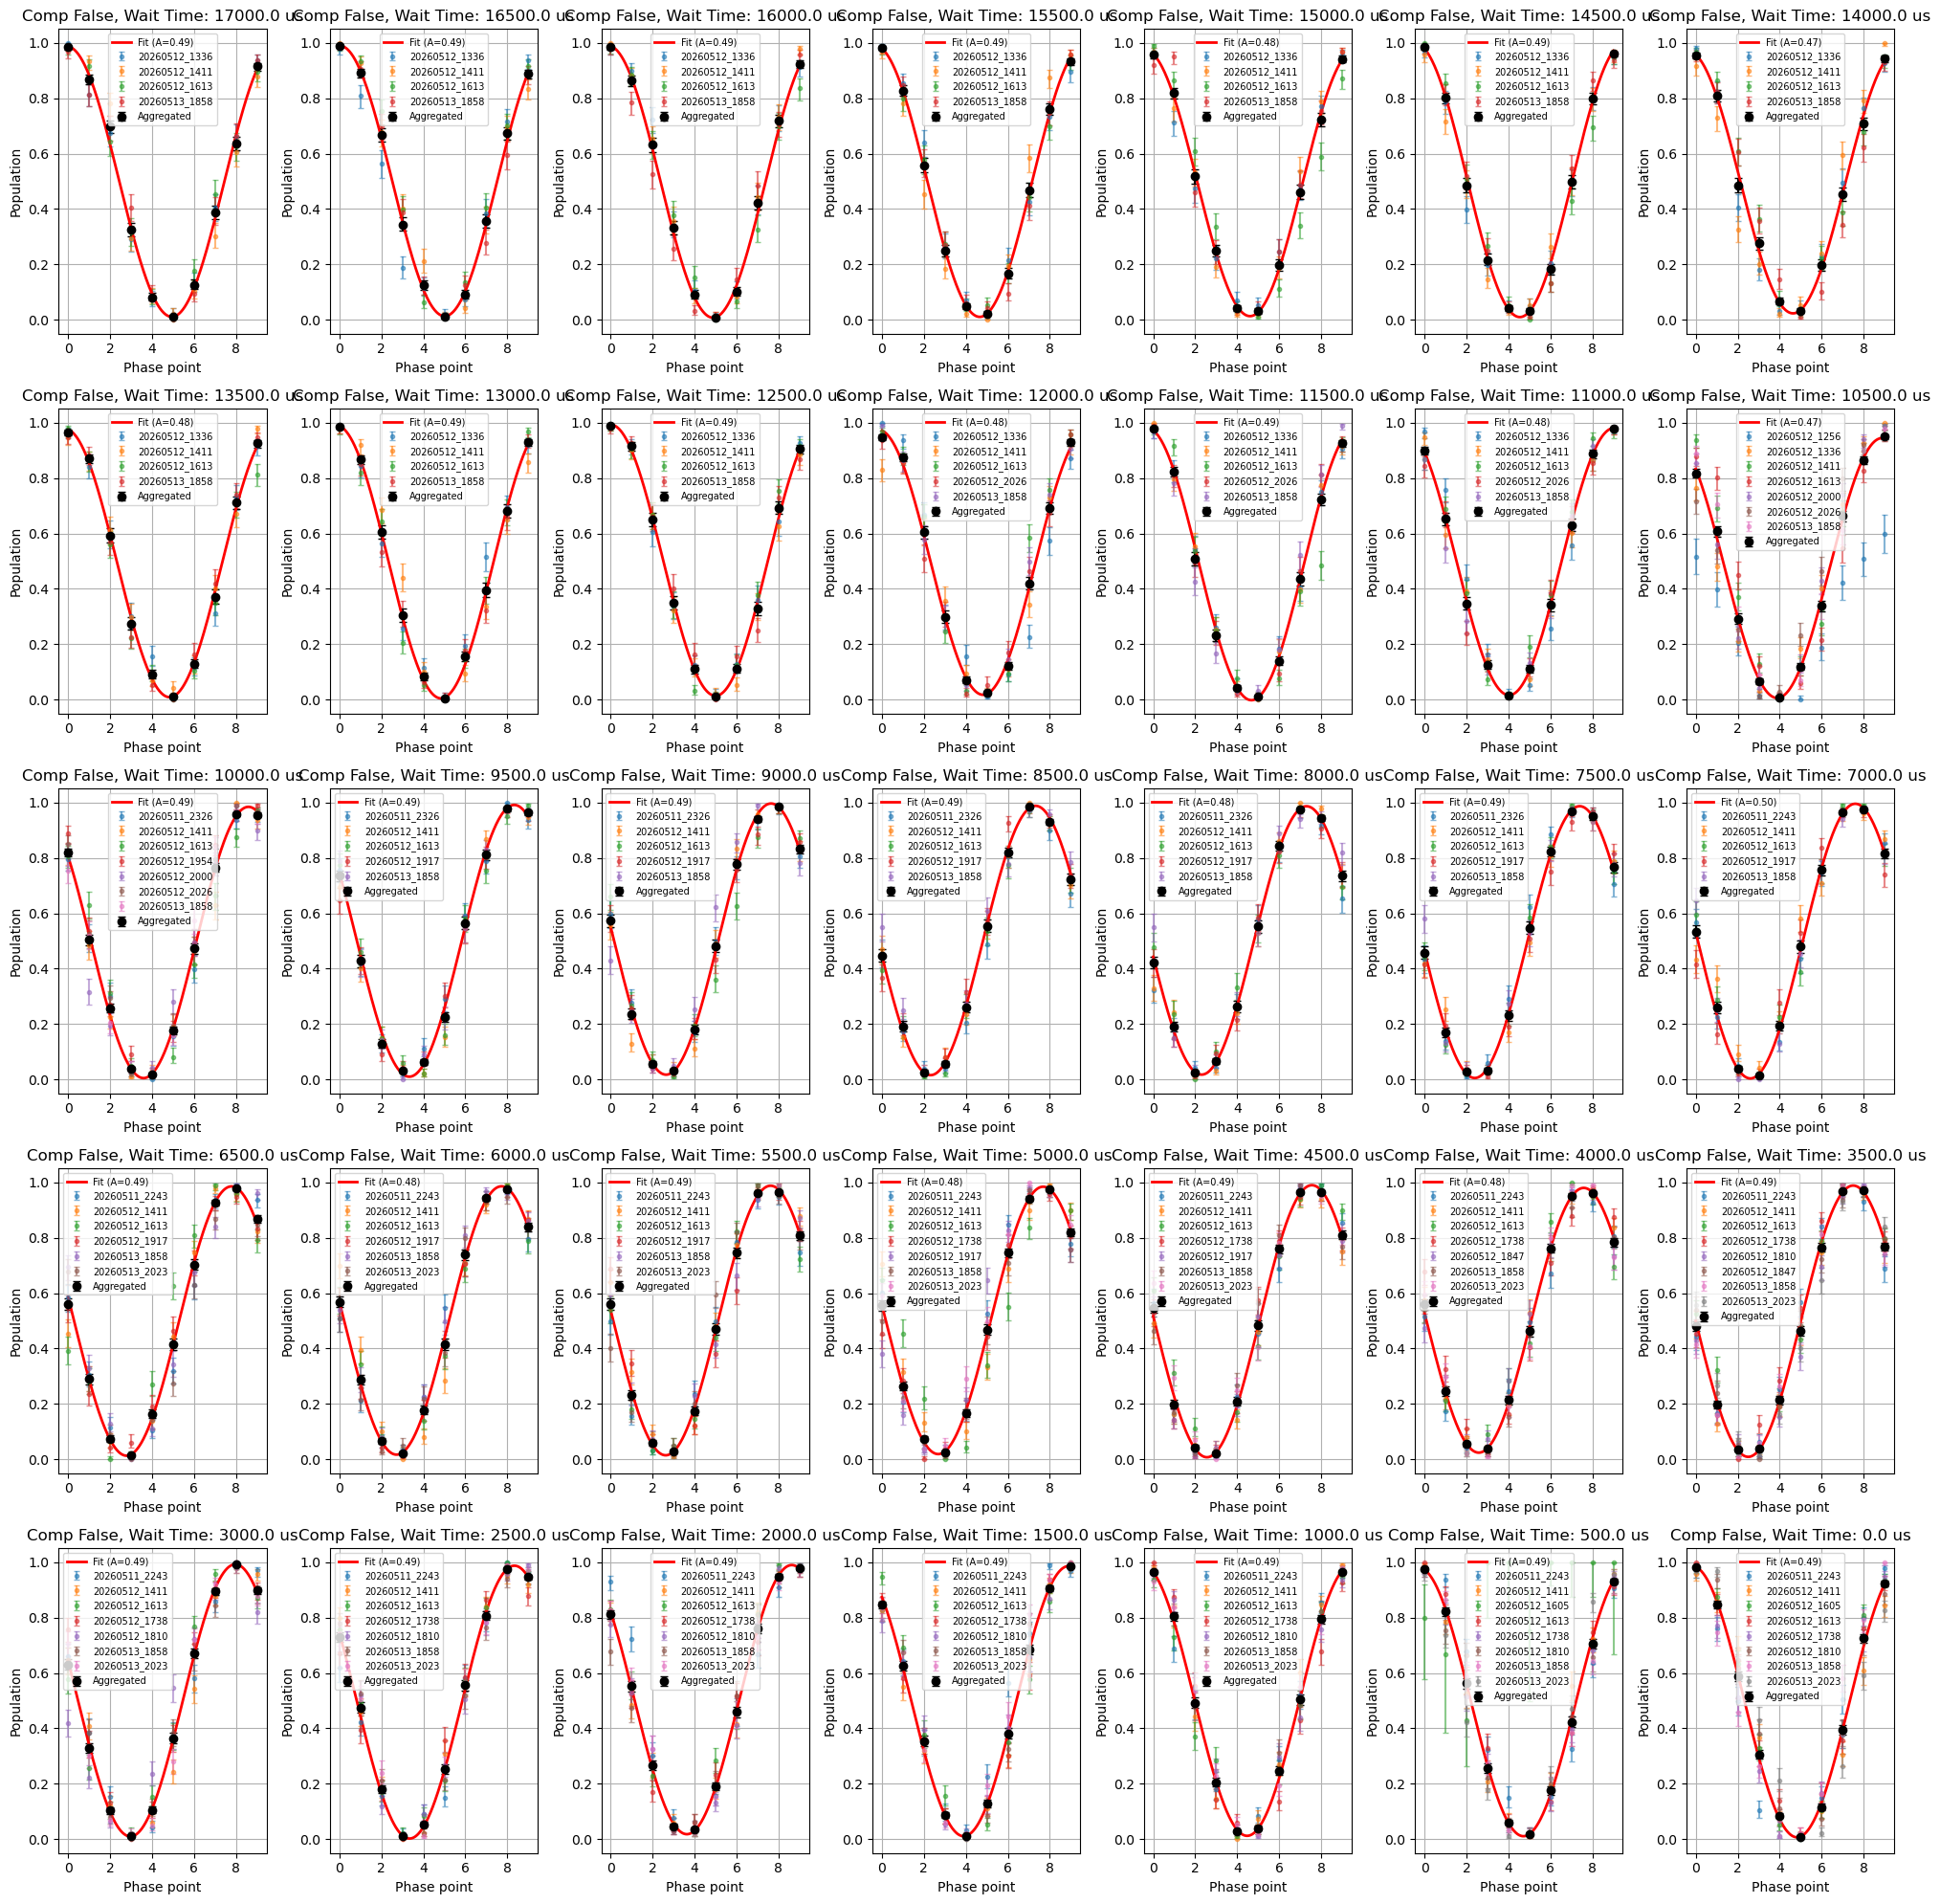


Fitting phase scans for Comp True


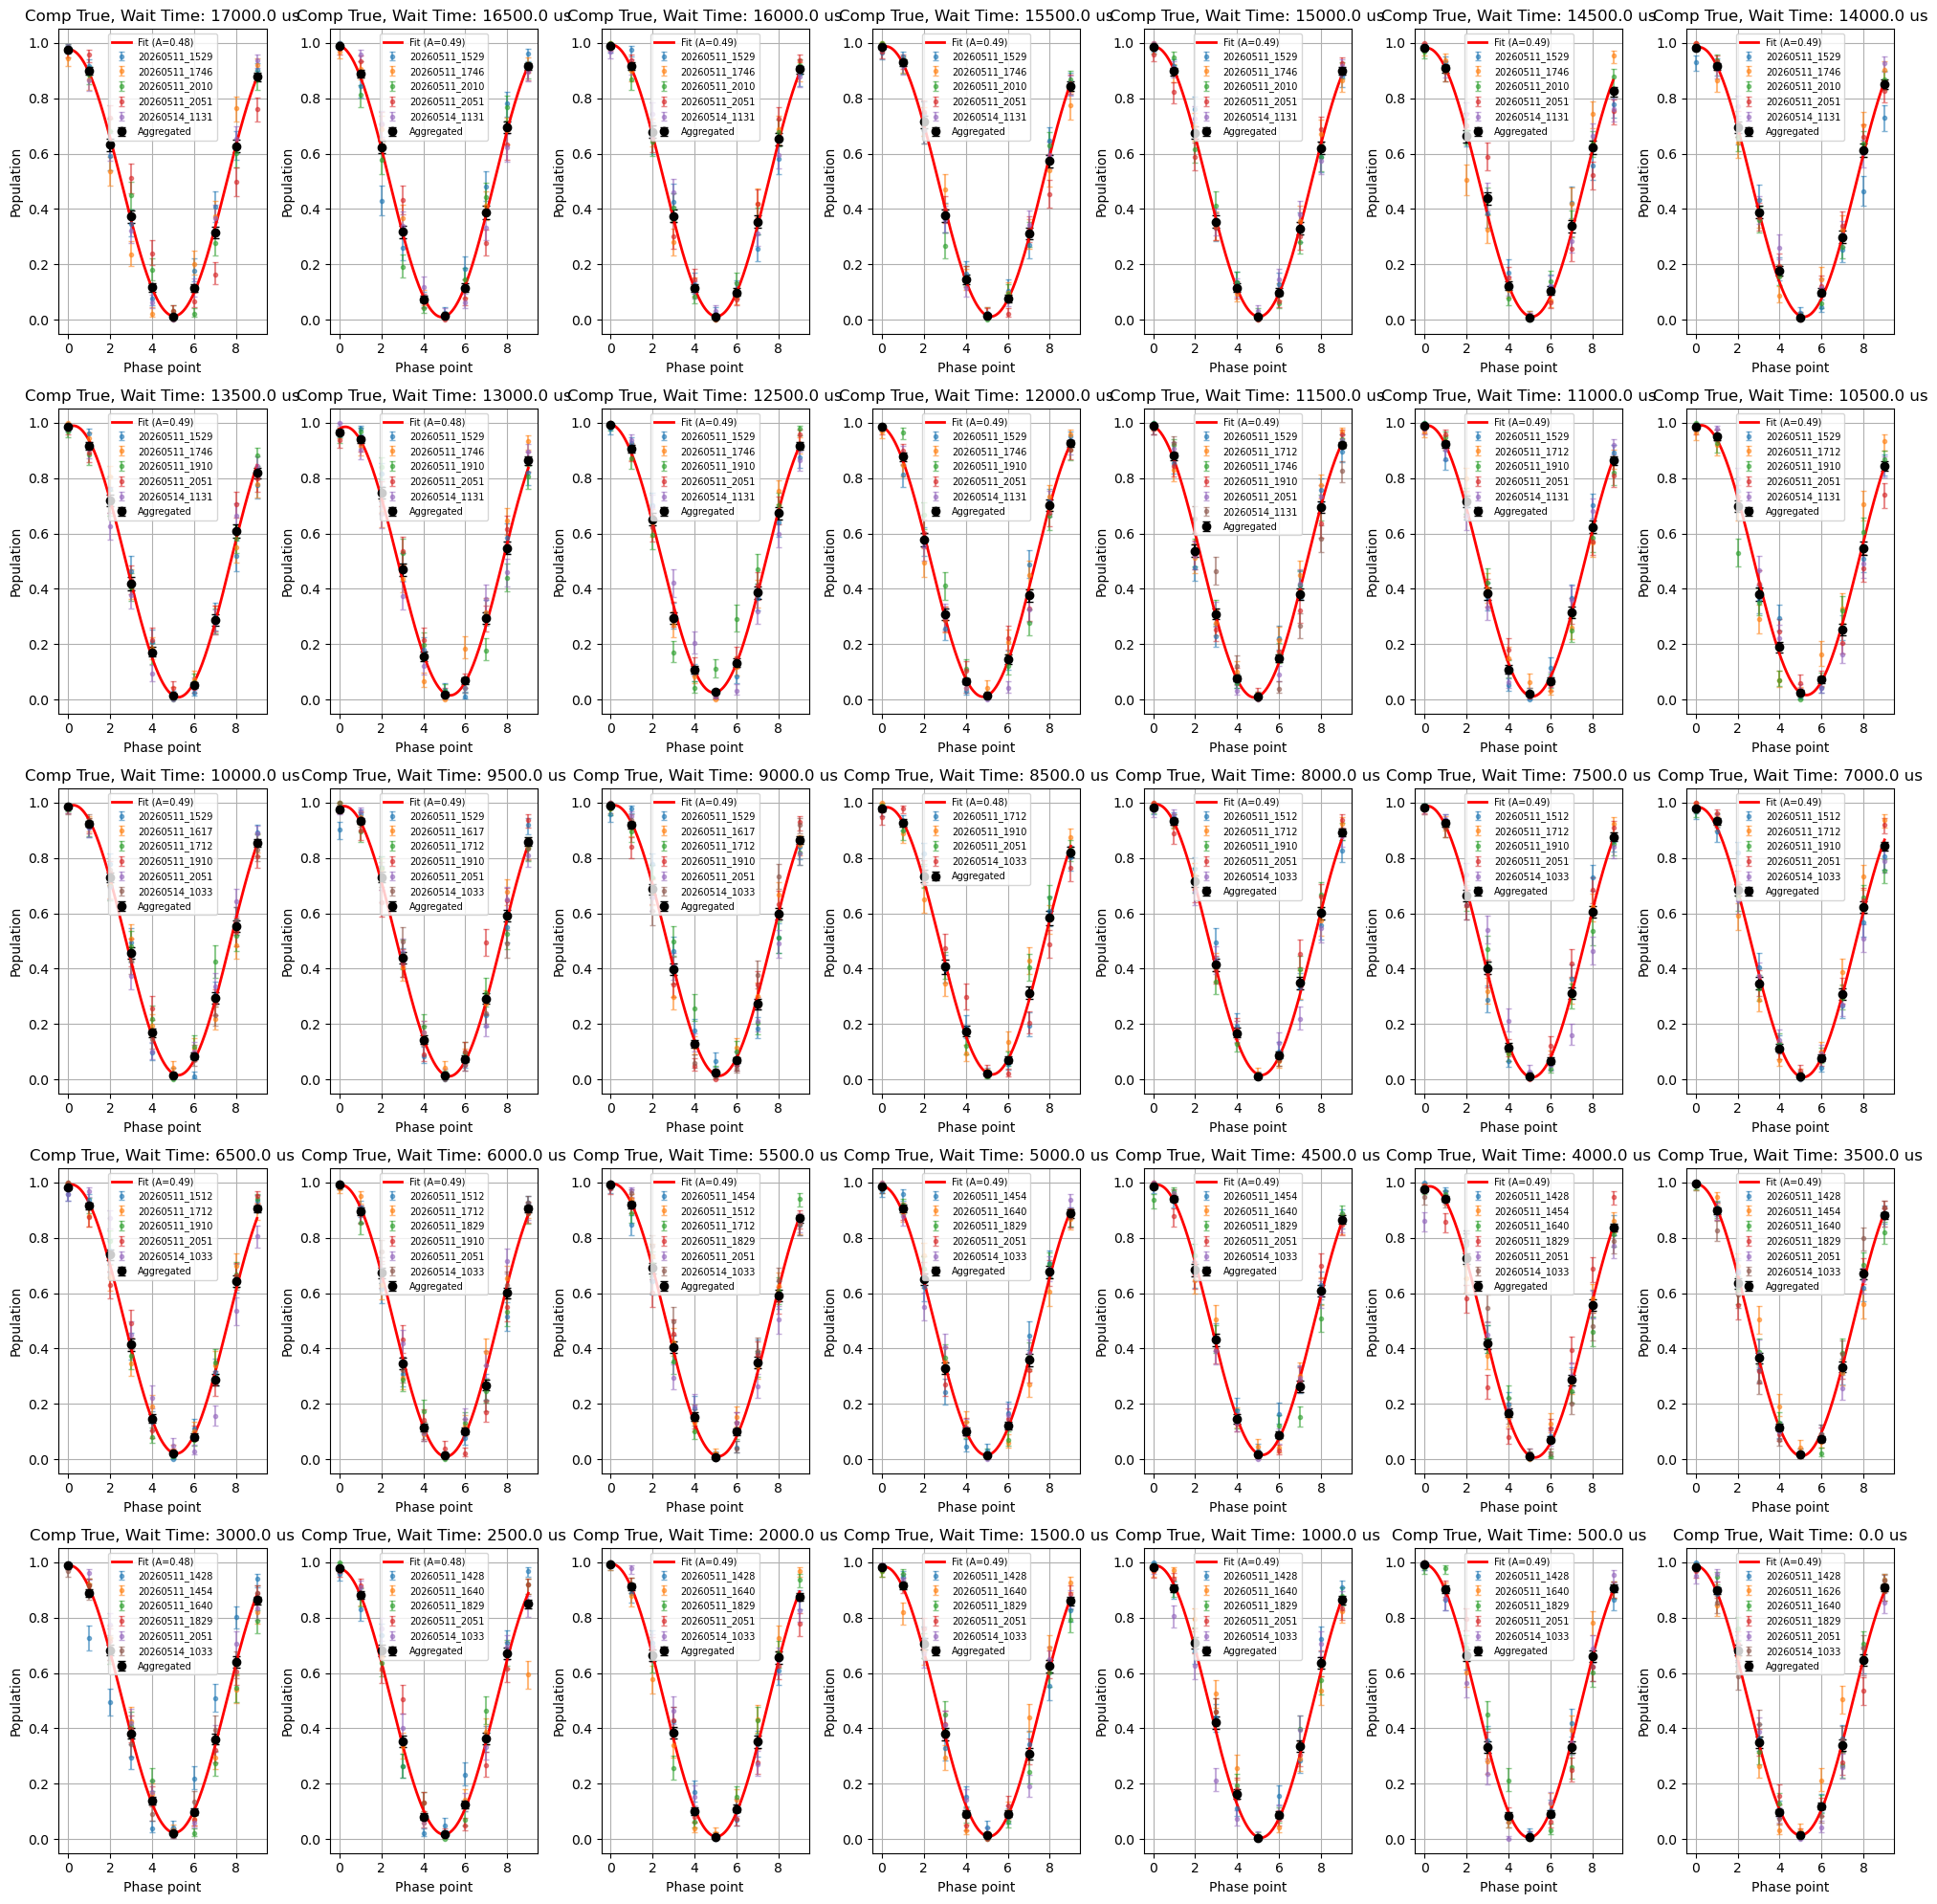

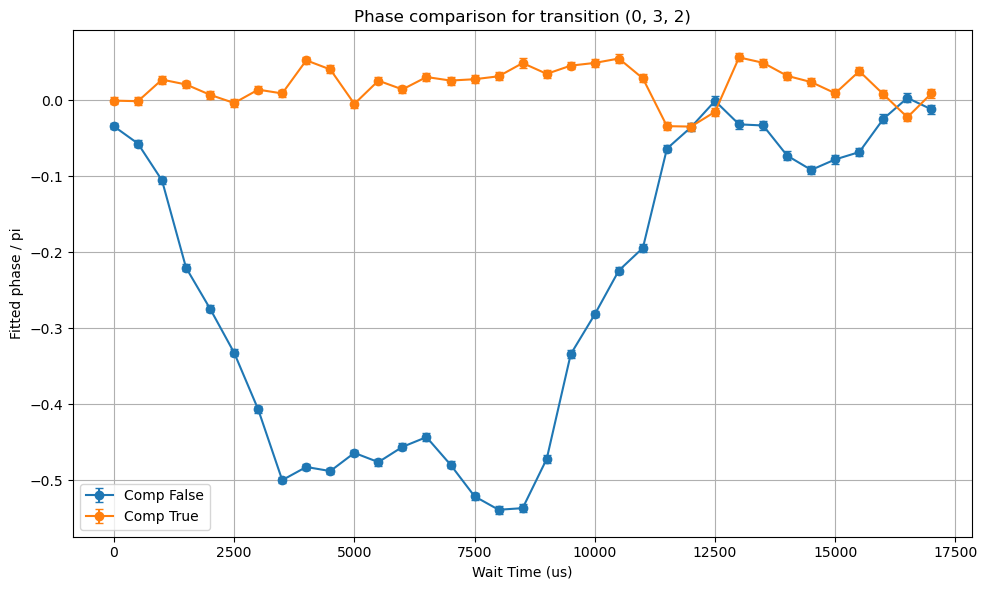


Fitted phase results:

Comp False
  Wait Time: 0.0 us
    Params (A, phi, offset) = 0.490, -0.108, 0.497
    Amplitude (2*|A|) = 0.979 +/- 0.005
    Phase = -0.108 +/- 0.013
  Wait Time: 500.0 us
    Params (A, phi, offset) = 0.485, -0.179, 0.496
    Amplitude (2*|A|) = 0.970 +/- 0.007
    Phase = -0.179 +/- 0.014
  Wait Time: 1000.0 us
    Params (A, phi, offset) = 0.489, -0.331, 0.501
    Amplitude (2*|A|) = 0.979 +/- 0.007
    Phase = -0.331 +/- 0.013
  Wait Time: 1500.0 us
    Params (A, phi, offset) = 0.488, -0.692, 0.498
    Amplitude (2*|A|) = 0.975 +/- 0.005
    Phase = -0.692 +/- 0.014
  Wait Time: 2000.0 us
    Params (A, phi, offset) = 0.486, -0.862, 0.504
    Amplitude (2*|A|) = 0.972 +/- 0.007
    Phase = -0.862 +/- 0.014
  Wait Time: 2500.0 us
    Params (A, phi, offset) = 0.493, -1.044, 0.495
    Amplitude (2*|A|) = 0.985 +/- 0.006
    Phase = -1.044 +/- 0.013
  Wait Time: 3000.0 us
    Params (A, phi, offset) = 0.491, -1.278, 0.501
    Amplitude (2*|A|) = 0.983 +/- 0.0

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def sine_function(t, A, phi, offset):
    return A * np.cos(2 * np.pi / 10 * t - phi) + offset


def fit_sine_curve(ket_data, lower_error, upper_error):
    ket_data = np.array(ket_data, dtype=float)
    lower_error = np.array(lower_error, dtype=float)
    upper_error = np.array(upper_error, dtype=float)

    if len(ket_data) == 5:
        t = 2 * np.arange(len(ket_data))
    else:
        t = np.arange(len(ket_data))

    valid_indices = np.isfinite(ket_data) & np.isfinite(lower_error) & np.isfinite(upper_error)
    if np.count_nonzero(valid_indices) < 4:
        return None, None

    t_valid = t[valid_indices]
    ket_data_valid = ket_data[valid_indices]
    lower_error_valid = lower_error[valid_indices]
    upper_error_valid = upper_error[valid_indices]

    sigma = (upper_error_valid + lower_error_valid) / 2.0
    if np.any(sigma <= 0):
        nonzero = sigma[sigma > 0]
        replacement = np.min(nonzero) if len(nonzero) > 0 else 1.0
        sigma[sigma <= 0] = replacement

    A0 = (np.max(ket_data_valid) - np.min(ket_data_valid)) / 2
    A0 = float(np.clip(A0, 1e-6, 0.5))
    offset0 = float(np.clip(np.mean(ket_data_valid), 0.0, 1.0))
    initial_guess = [A0, 0.0, offset0]

    try:
        params, covariance = curve_fit(
            sine_function,
            t_valid,
            ket_data_valid,
            p0=initial_guess,
            sigma=sigma,
            absolute_sigma=True,
            maxfev=10000,
            bounds=([0.0, -np.pi, 0.0], [0.5, np.pi, 1.0]),
        )
        if covariance is not None:
            errors = np.sqrt(np.diag(covariance))
            errors = [err if np.isfinite(err) else None for err in errors]
        else:
            errors = [None] * len(params)
        return params, errors
    except RuntimeError:
        return None, None


def fit_all_wait_times_to_sine_in_lists(wait_time_list, ket_data_list, lower_error_list, upper_error_list):
    fit_wait_times_list = []
    fit_params_list = []
    fit_amplitudes_list = []
    fit_amplitude_errors_list = []
    fit_phases_list = []
    fit_phase_errors_list = []

    for wt, kd, le, ue in zip(wait_time_list, ket_data_list, lower_error_list, upper_error_list):
        params, errors = fit_sine_curve(kd, le, ue)
        fit_wait_times_list.append(wt)

        if params is not None and errors is not None and errors[0] is not None:
            A, phi, offset = params
            amplitude = 2.0 * abs(A)
            amplitude_error = 2.0 * errors[0] if errors[0] is not None else None
            phase_error = errors[1]

            fit_params_list.append(params)
            fit_amplitudes_list.append(amplitude)
            fit_amplitude_errors_list.append(amplitude_error)
            fit_phases_list.append(phi)
            fit_phase_errors_list.append(phase_error)
        else:
            fit_params_list.append([None, None, None])
            fit_amplitudes_list.append(None)
            fit_amplitude_errors_list.append(None)
            fit_phases_list.append(None)
            fit_phase_errors_list.append(None)

    return (
        fit_wait_times_list,
        fit_params_list,
        fit_amplitudes_list,
        fit_amplitude_errors_list,
        fit_phases_list,
        fit_phase_errors_list,
    )


def plot_sine_fits_in_lists(
    wait_time_list,
    ket_data_list,
    lower_error_list,
    upper_error_list,
    fit_params_list,
    comp_flag,
    individual_runs_by_wait_time=None,
):
    num_plots = len(wait_time_list)
    if num_plots == 0:
        print(f"Comp {comp_flag}: no phase scans to plot.")
        return

    num_columns = min(7, num_plots)
    num_rows = (num_plots + num_columns - 1) // num_columns
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(20, 4 * num_rows), squeeze=False)
    axes = axes.flatten()
    colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [f"C{i}" for i in range(10)])

    plot_indices = list(range(num_plots))[::-1]
    for ax_index, data_index in enumerate(plot_indices):
        wt = wait_time_list[data_index]
        kd = np.array(ket_data_list[data_index], dtype=float)
        le = np.array(lower_error_list[data_index], dtype=float)
        ue = np.array(upper_error_list[data_index], dtype=float)
        params = fit_params_list[data_index]
        t = 2 * np.arange(len(kd)) if len(kd) == 5 else np.arange(len(kd))
        valid = np.isfinite(kd) & np.isfinite(le) & np.isfinite(ue)

        ax = axes[ax_index]

        if individual_runs_by_wait_time is not None and data_index < len(individual_runs_by_wait_time):
            for run_index, run in enumerate(individual_runs_by_wait_time[data_index]):
                run_kd = np.array(run["ket_data"], dtype=float)
                run_le = np.array(run["lower_error"], dtype=float)
                run_ue = np.array(run["upper_error"], dtype=float)
                run_t = 2 * np.arange(len(run_kd)) if len(run_kd) == 5 else np.arange(len(run_kd))
                run_valid = np.isfinite(run_kd) & np.isfinite(run_le) & np.isfinite(run_ue)
                if not np.any(run_valid):
                    continue

                color = colors[run_index % len(colors)]
                ax.errorbar(
                    run_t[run_valid],
                    run_kd[run_valid],
                    yerr=[np.abs(run_le[run_valid]), np.abs(run_ue[run_valid])],
                    fmt="o",
                    markersize=3,
                    capsize=2,
                    alpha=0.55,
                    color=color,
                    ecolor=color,
                    label=run["label"],
                )

        ax.errorbar(
            t[valid],
            kd[valid],
            yerr=[np.abs(le[valid]), np.abs(ue[valid])],
            fmt="o",
            markersize=6,
            capsize=3,
            color="black",
            ecolor="black",
            label="Aggregated",
        )

        A, phi, offset = params
        if A is not None and np.any(valid):
            t_fit = np.linspace(t[valid].min(), t[valid].max(), 400)
            fit_curve = sine_function(t_fit, A, phi, offset)
            ax.plot(t_fit, fit_curve, color="red", linewidth=2.0, label=f"Fit (A={A:.2f})")

        ax.set_title(f"Comp {comp_flag}, Wait Time: {wt} us")
        ax.set_xlabel("Phase point")
        ax.set_ylim(-0.05, 1.05)
        ax.set_ylabel("Population")
        ax.grid()
        ax.legend(fontsize=7)

    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.savefig(f"laser_noise_phase_scans_comp_{str(comp_flag).lower()}.png", dpi=300)
    plt.show()

def fit_phase_for_all_comp_groups(processed_data_by_comp, do_plot=True):
    phase_fit_results_by_comp = {}
    for comp_flag in (False, True):
        data = processed_data_by_comp[comp_flag]
        wait_times = data["processed_wait_times"]
        if len(wait_times) == 0:
            phase_fit_results_by_comp[comp_flag] = {
                "fit_wait_times_list": [],
                "fit_params_list": [],
                "fit_amplitudes_list": [],
                "fit_amplitude_errors_list": [],
                "fit_phases_list": [],
                "fit_phase_errors_list": [],
            }
            continue

        print(f"\nFitting phase scans for Comp {comp_flag}")
        (
            fit_wait_times_list,
            fit_params_list,
            fit_amplitudes_list,
            fit_amplitude_errors_list,
            fit_phases_list,
            fit_phase_errors_list,
        ) = fit_all_wait_times_to_sine_in_lists(
            wait_times,
            data["ket_data_list"],
            data["lower_error_list"],
            data["upper_error_list"],
        )

        phase_fit_results_by_comp[comp_flag] = {
            "fit_wait_times_list": fit_wait_times_list,
            "fit_params_list": fit_params_list,
            "fit_amplitudes_list": fit_amplitudes_list,
            "fit_amplitude_errors_list": fit_amplitude_errors_list,
            "fit_phases_list": fit_phases_list,
            "fit_phase_errors_list": fit_phase_errors_list,
        }

        if do_plot:
            plot_sine_fits_in_lists(
                wait_times,
                data["ket_data_list"],
                data["lower_error_list"],
                data["upper_error_list"],
                fit_params_list,
                comp_flag,
                individual_runs_by_wait_time=data.get("individual_runs_by_wait_time"),
            )

    return phase_fit_results_by_comp


phase_fit_results_by_comp = fit_phase_for_all_comp_groups(processed_data_by_comp, do_plot=True)

active_phase_fit = phase_fit_results_by_comp[active_comp_flag]
fit_wait_times_list = active_phase_fit["fit_wait_times_list"]
fit_params_list = active_phase_fit["fit_params_list"]
fit_amplitudes_list = active_phase_fit["fit_amplitudes_list"]
fit_amplitude_errors_list = active_phase_fit["fit_amplitude_errors_list"]
fit_phases_list = active_phase_fit["fit_phases_list"]
fit_phase_errors_list = active_phase_fit["fit_phase_errors_list"]

def plot_phase_comparison_by_comp(phase_fit_results_by_comp, use_modulo=False):
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = {False: "C0", True: "C1"}

    plotted_any = False
    for comp_flag in (False, True):
        result = phase_fit_results_by_comp[comp_flag]
        wait_times = np.array(result["fit_wait_times_list"], dtype=float)
        phases = np.array([np.nan if p is None else p for p in result["fit_phases_list"]], dtype=float)
        phase_errors = np.array([np.nan if e is None else e for e in result["fit_phase_errors_list"]], dtype=float)

        valid = np.isfinite(wait_times) & np.isfinite(phases) & np.isfinite(phase_errors)
        if not np.any(valid):
            print(f"Comp {comp_flag}: no finite phase points for comparison plot.")
            continue

        wait_times = wait_times[valid]
        phases = phases[valid]
        phase_errors = phase_errors[valid]
        order = np.argsort(wait_times)
        wait_times = wait_times[order]
        phases = phases[order]
        phase_errors = phase_errors[order]

        if use_modulo:
            y = np.mod(phases, 2 * np.pi) / np.pi
            yerr = phase_errors / np.pi
            ylabel = "Fitted phase mod 2pi / pi"
        else:
            y = phases / np.pi
            yerr = phase_errors / np.pi
            ylabel = "Fitted phase / pi"

        ax.errorbar(
            wait_times,
            y,
            yerr=yerr,
            fmt="o-",
            capsize=3,
            color=colors[comp_flag],
            ecolor=colors[comp_flag],
            label=f"Comp {comp_flag}",
        )
        plotted_any = True

    if not plotted_any:
        return None

    ax.set_xlabel("Wait Time (us)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"Phase comparison for transition {target_transition}")
    ax.grid()
    ax.legend()
    plt.tight_layout()
    plt.savefig("phase_comparison_comp_false_true.png", dpi=300)
    plt.show()
    return ax


plot_phase_comparison_by_comp(phase_fit_results_by_comp, use_modulo=False)

print("\nFitted phase results:")
for comp_flag in (False, True):
    result = phase_fit_results_by_comp[comp_flag]
    print(f"\nComp {comp_flag}")
    for i, wt in enumerate(result["fit_wait_times_list"]):
        A, phi, offset = result["fit_params_list"][i]
        amp = result["fit_amplitudes_list"][i]
        amp_err = result["fit_amplitude_errors_list"][i]
        phase = result["fit_phases_list"][i]
        phase_err = result["fit_phase_errors_list"][i]
        if A is None:
            print(f"  Wait Time: {wt} us | phase fit failed")
        else:
            print(f"  Wait Time: {wt} us")
            print(f"    Params (A, phi, offset) = {A:.3f}, {phi:.3f}, {offset:.3f}")
            print(f"    Amplitude (2*|A|) = {amp:.3f} +/- {amp_err:.3f}")
            print(f"    Phase = {phase:.3f} +/- {phase_err:.3f}")



Fitting detuning scans for Comp False


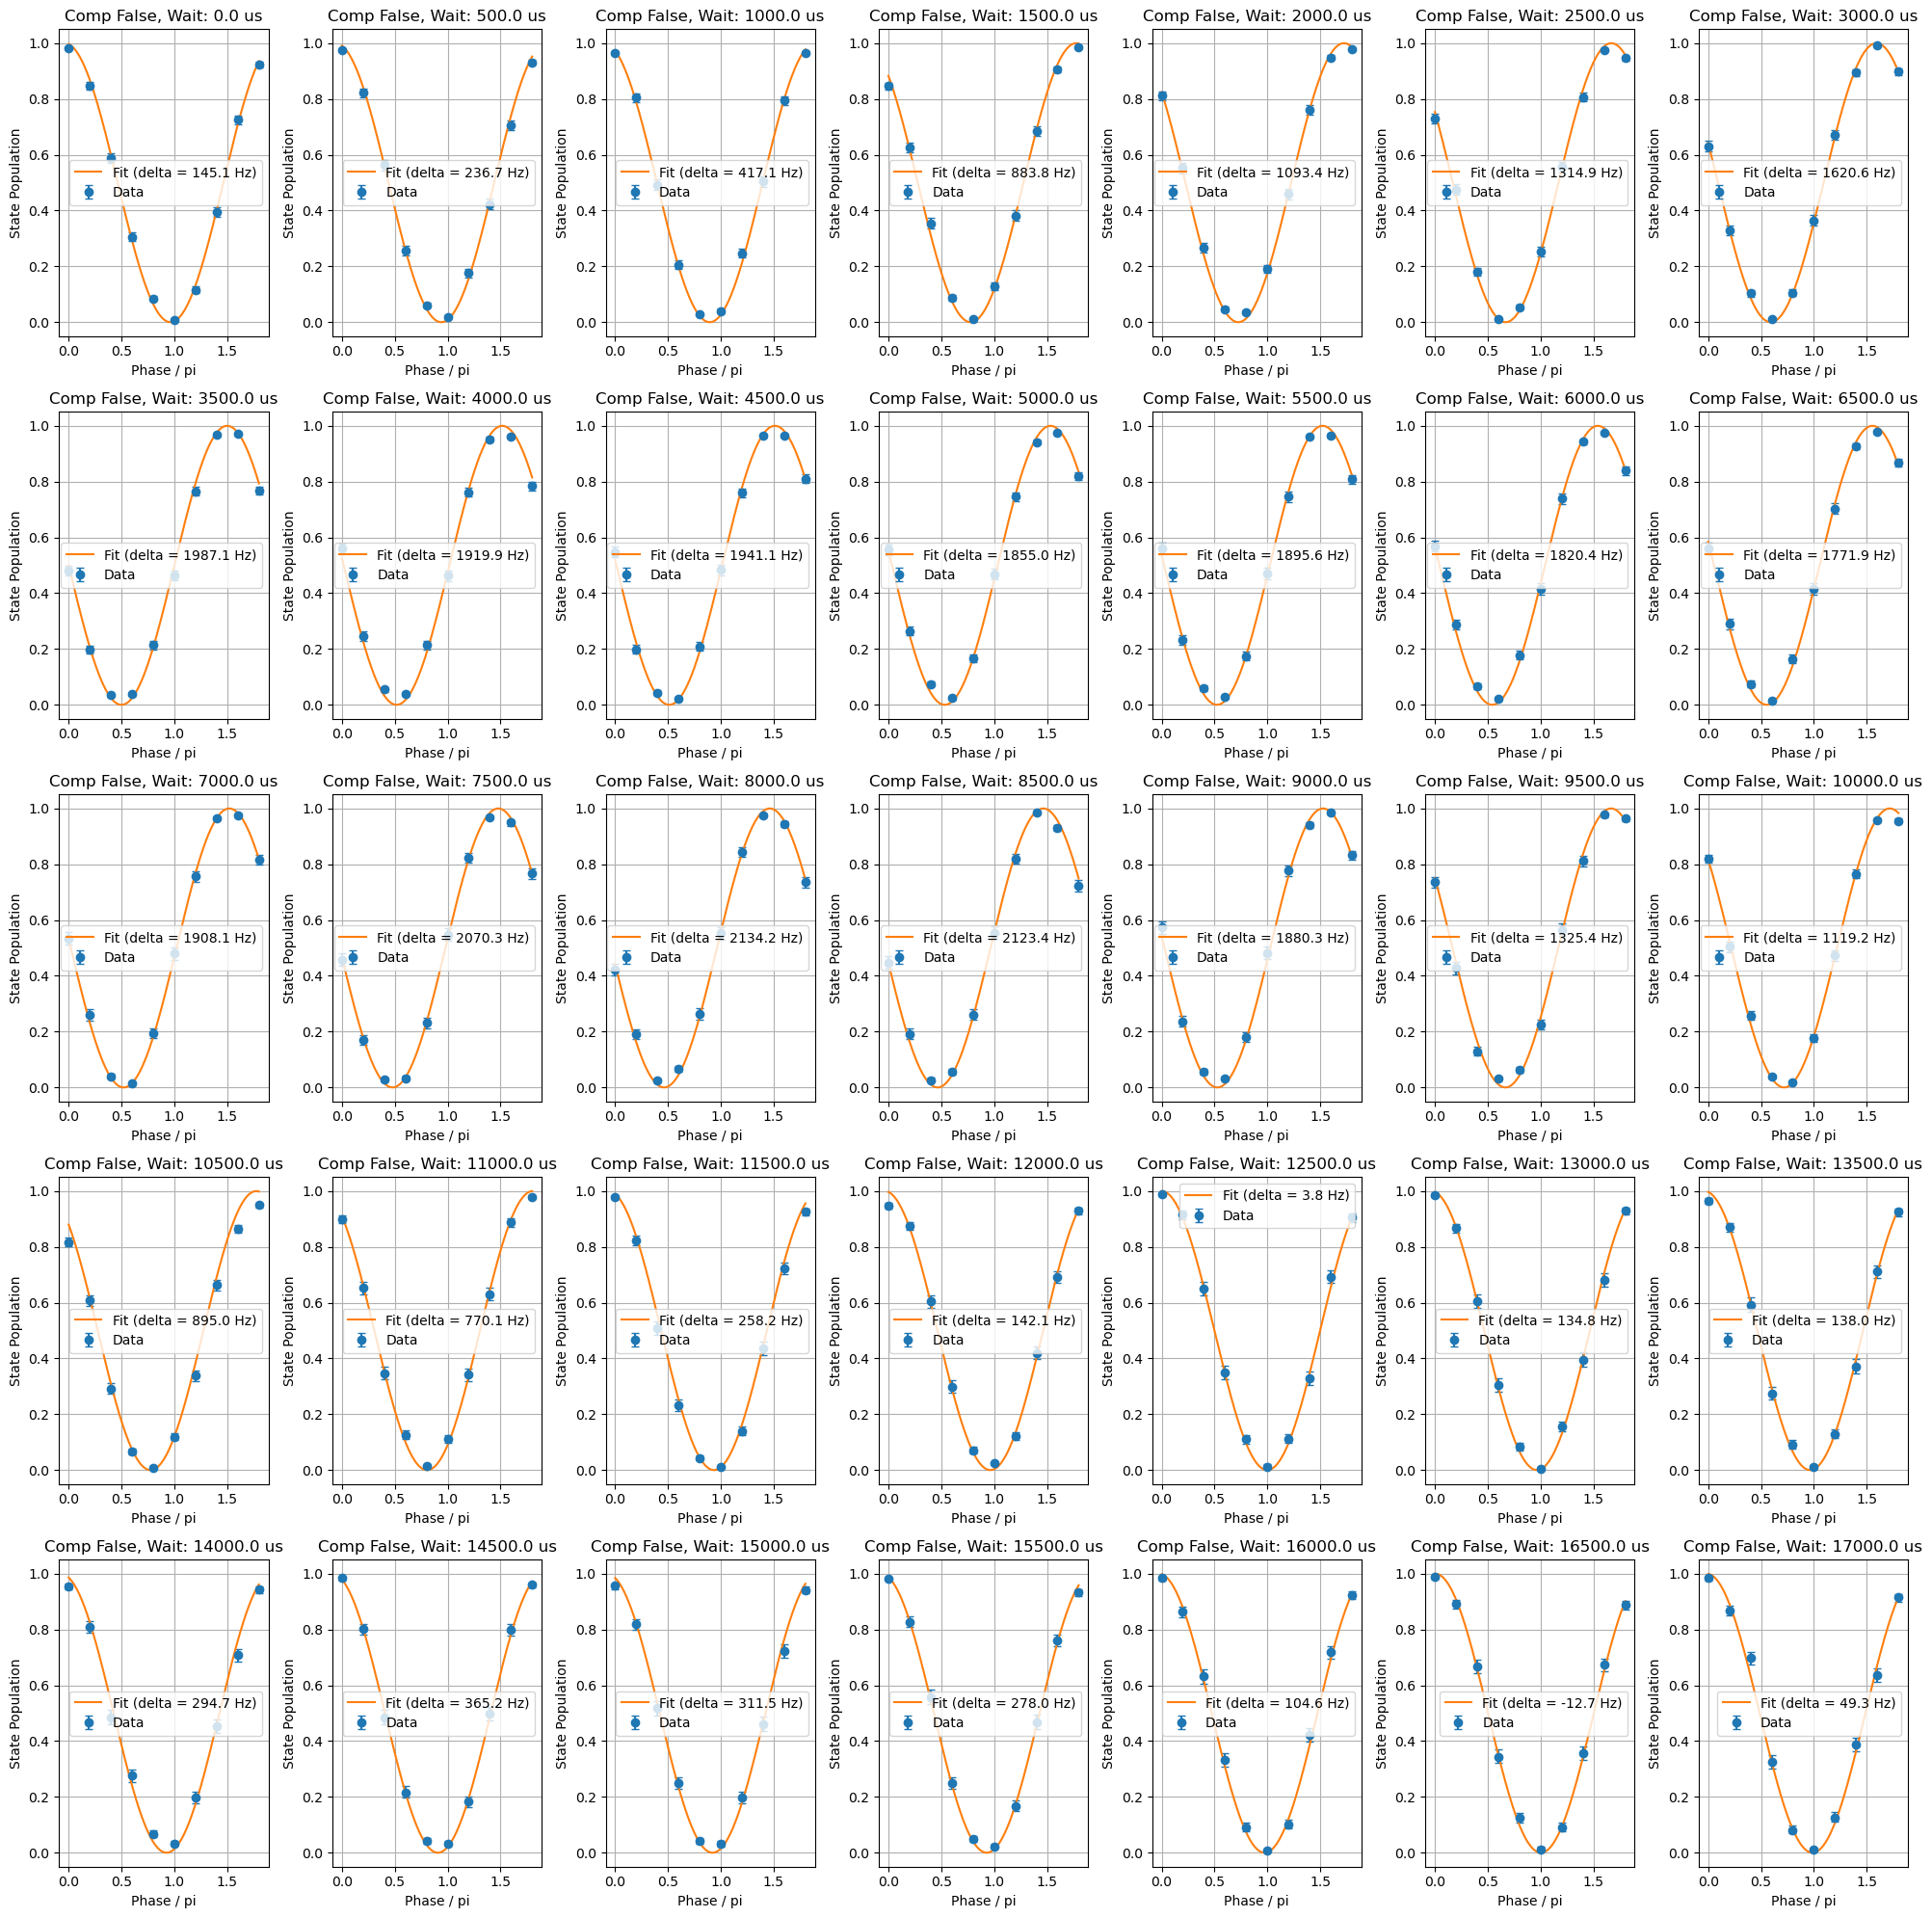


Fitting detuning scans for Comp True


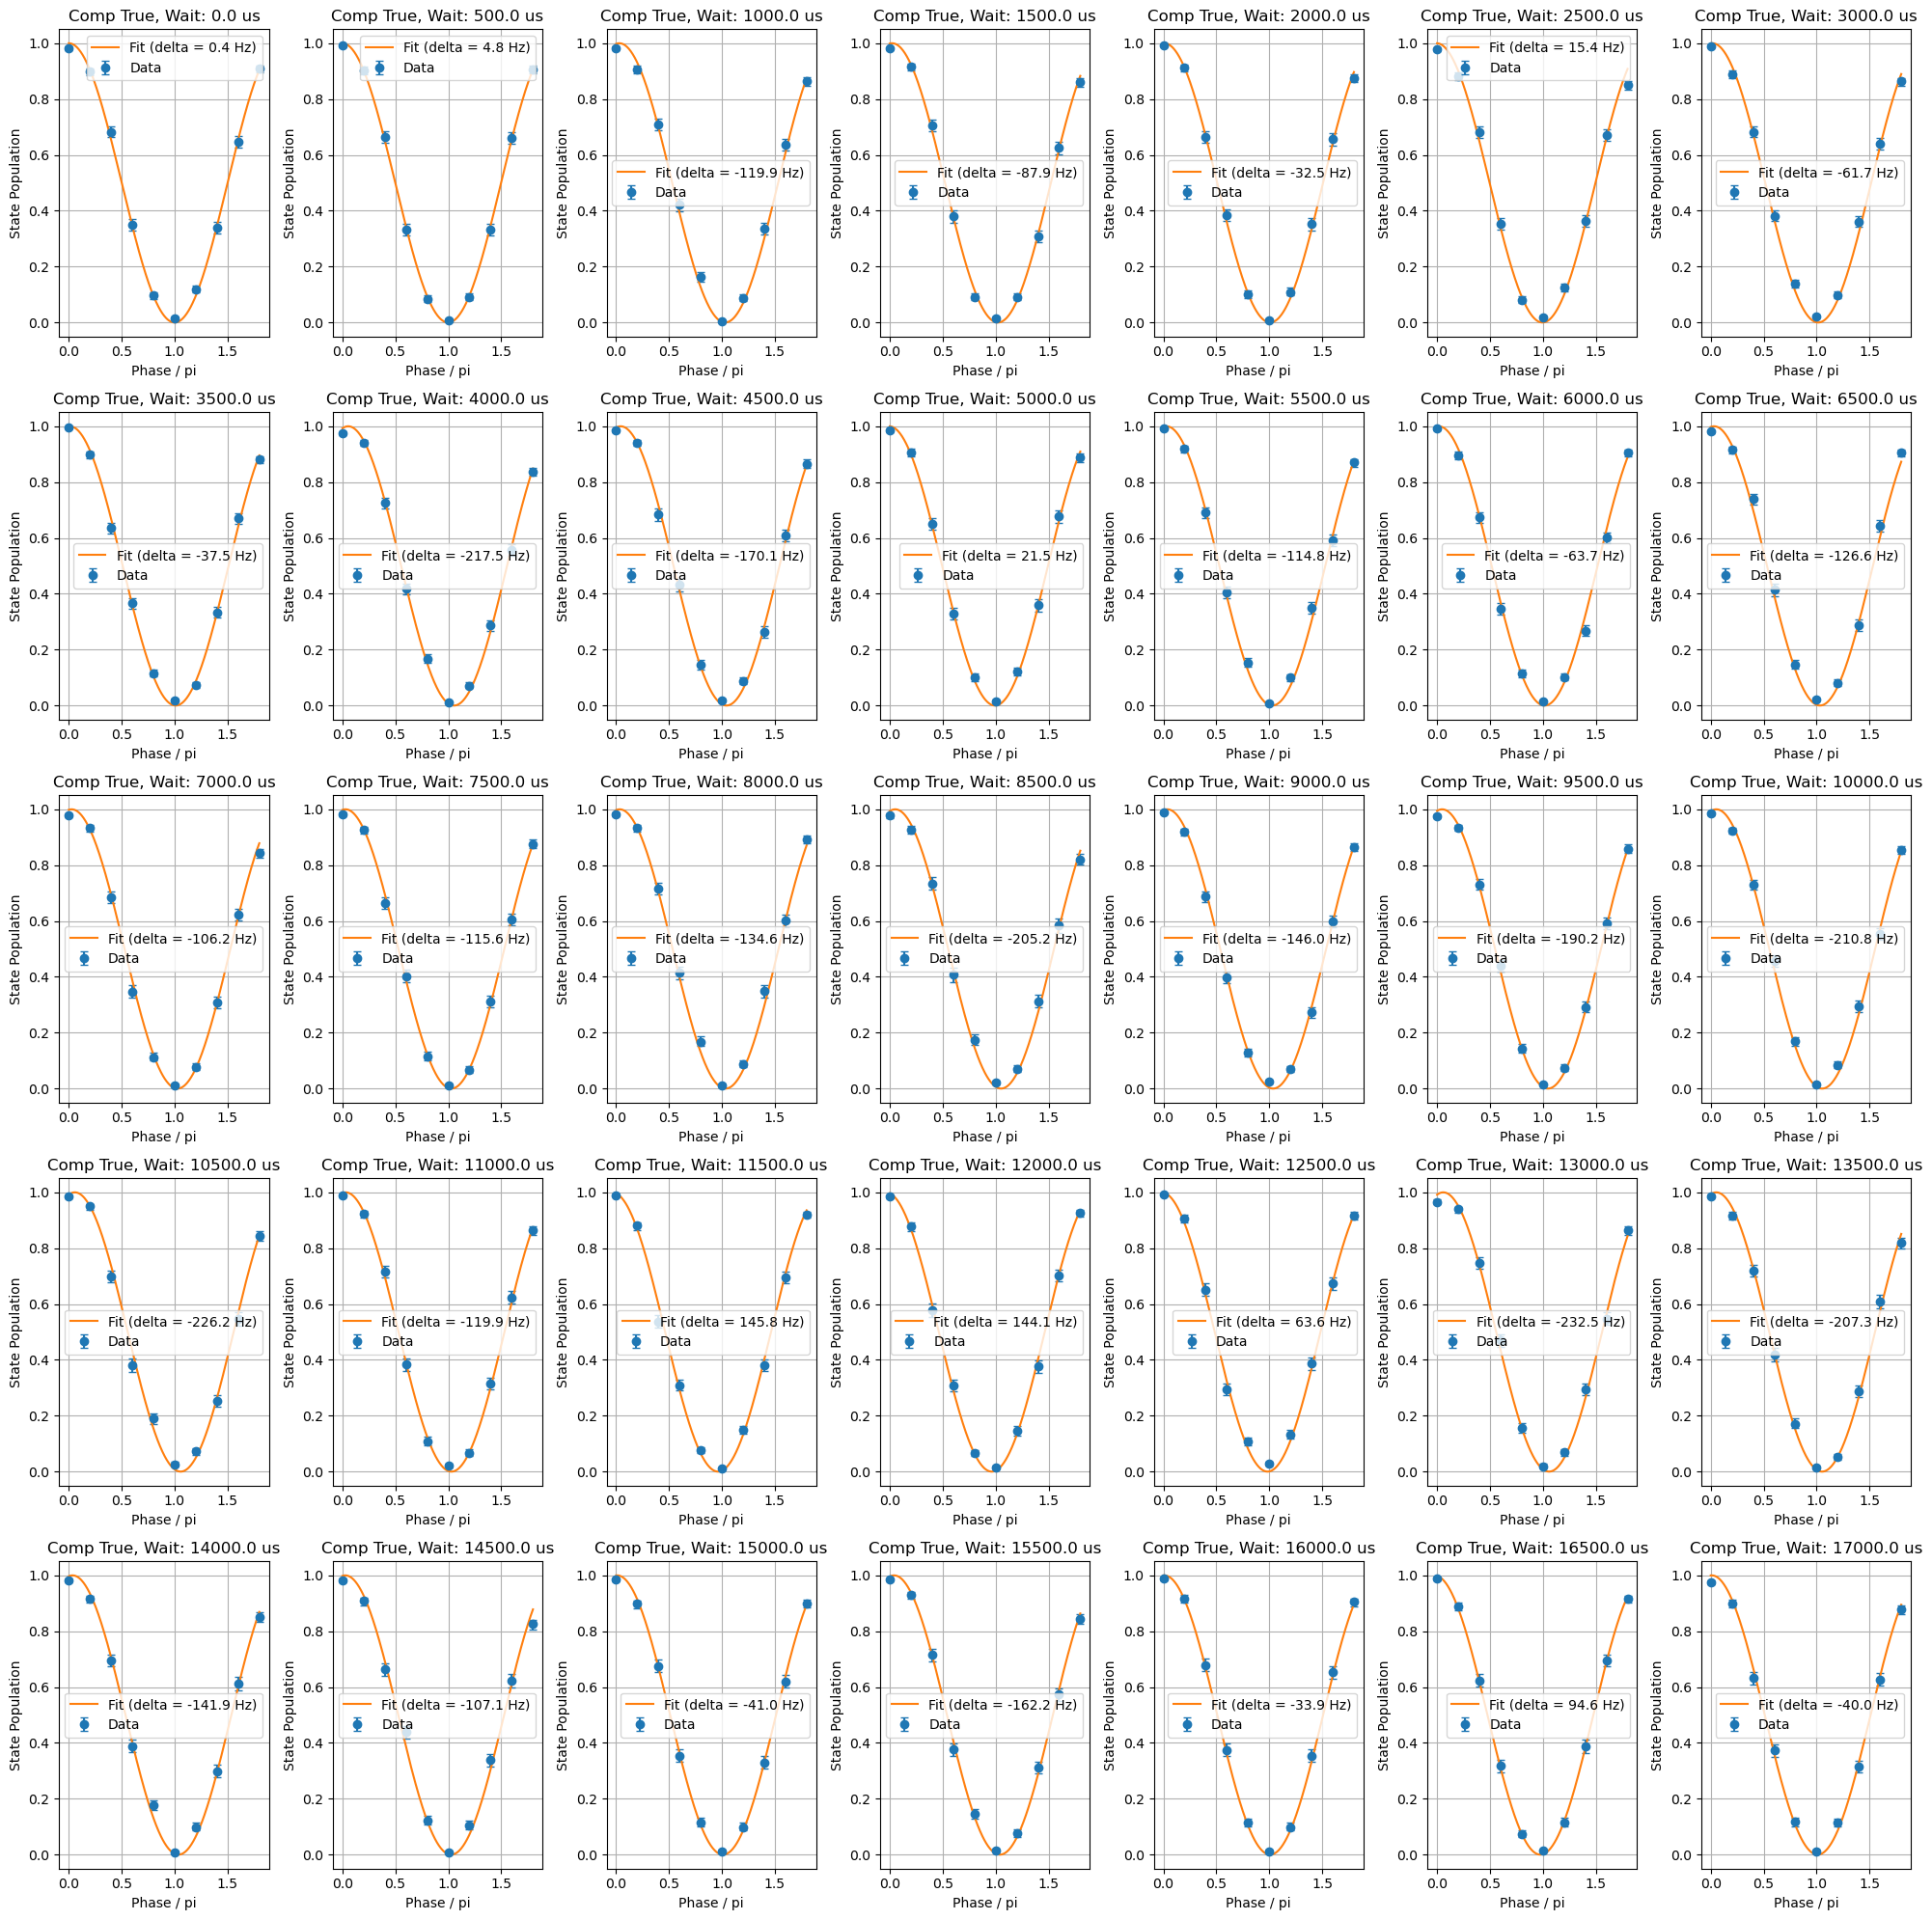


Fitted detunings:

Comp False
  0.0 us: delta = 145.144 Hz +/- 15.939 Hz
  500.0 us: delta = 236.698 Hz +/- 17.044 Hz
  1000.0 us: delta = 417.134 Hz +/- 16.393 Hz
  1500.0 us: delta = 883.823 Hz +/- 17.531 Hz
  2000.0 us: delta = 1093.383 Hz +/- 16.609 Hz
  2500.0 us: delta = 1314.945 Hz +/- 16.098 Hz
  3000.0 us: delta = 1620.607 Hz +/- 17.324 Hz
  3500.0 us: delta = 1987.109 Hz +/- 15.205 Hz
  4000.0 us: delta = 1919.880 Hz +/- 17.075 Hz
  4500.0 us: delta = 1941.110 Hz +/- 16.138 Hz
  5000.0 us: delta = 1855.011 Hz +/- 16.927 Hz
  5500.0 us: delta = 1895.587 Hz +/- 17.842 Hz
  6000.0 us: delta = 1820.353 Hz +/- 18.277 Hz
  6500.0 us: delta = 1771.900 Hz +/- 18.450 Hz
  7000.0 us: delta = 1908.122 Hz +/- 18.702 Hz
  7500.0 us: delta = 2070.299 Hz +/- 19.077 Hz
  8000.0 us: delta = 2134.240 Hz +/- 19.927 Hz
  8500.0 us: delta = 2123.408 Hz +/- 19.906 Hz
  9000.0 us: delta = 1880.322 Hz +/- 19.270 Hz
  9500.0 us: delta = 1325.389 Hz +/- 19.153 Hz
  10000.0 us: delta = 1119.164 Hz +/-

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import curve_fit


def unitary_product_with_ket_zero(pi_time, T_between_pulses, delta, phase_pi):
    omega = np.pi / (pi_time * 1e-6)
    t_pi_over_2 = (pi_time * 1e-6) / 2

    def U1(omega, t):
        H = np.array([[0, omega / 2], [omega / 2, delta]], dtype=complex)
        return expm(-1j * H * t)

    def U_wait(delta, t):
        H = np.array([[0, 0], [0, delta]], dtype=complex)
        return expm(-1j * H * t)

    def U2(omega, delta, phase_pi, t):
        phase = np.pi * phase_pi
        H = np.array(
            [[0, omega * np.exp(-1j * phase) / 2], [omega * np.exp(1j * phase) / 2, delta]],
            dtype=complex,
        )
        return expm(-1j * H * t)

    product = U2(omega, delta, phase_pi, t_pi_over_2) @ U_wait(delta, T_between_pulses) @ U1(omega, t_pi_over_2)
    ket_zero = np.array([1, 0], dtype=complex)
    result = product @ ket_zero
    state_pop = np.abs(result) ** 2
    return state_pop[1]


def fit_detuning_for_one_dataset(
    ket_data,
    lower_error,
    upper_error,
    phase_list,
    pi_time,
    T_between_pulses,
    initial_delta_guess=2 * np.pi * 100,
):
    ket_data = np.array(ket_data, dtype=float)
    lower_error = np.array(lower_error, dtype=float)
    upper_error = np.array(upper_error, dtype=float)
    phase_array = np.array(phase_list, dtype=float)

    if ket_data.shape[0] != phase_array.shape[0]:
        raise ValueError(f"ket_data has {ket_data.shape[0]} points but phase_list has {phase_array.shape[0]} points")

    valid = np.isfinite(ket_data) & np.isfinite(lower_error) & np.isfinite(upper_error)
    if np.count_nonzero(valid) < 4:
        return None, None

    phases_valid = phase_array[valid]
    ket_data_valid = ket_data[valid]
    lower_error_valid = lower_error[valid]
    upper_error_valid = upper_error[valid]

    sigma = (np.abs(upper_error_valid) + np.abs(lower_error_valid)) / 2.0
    if np.any(sigma <= 0):
        nonzero = sigma[sigma > 0]
        replacement = np.min(nonzero) if len(nonzero) > 0 else 1.0
        sigma[sigma <= 0] = replacement

    def ramsey_model(phase_pi, delta):
        return np.array([unitary_product_with_ket_zero(pi_time, T_between_pulses, delta, ph) for ph in phase_pi])

    try:
        params, covariance = curve_fit(
            ramsey_model,
            phases_valid,
            ket_data_valid,
            p0=[initial_delta_guess],
            sigma=sigma,
            absolute_sigma=True,
            maxfev=20000,
        )
        delta_opt = params[0]
        if covariance is not None:
            errors = np.sqrt(np.diag(covariance))
            delta_err = errors[0] if np.isfinite(errors[0]) else None
        else:
            delta_err = None
        return delta_opt, delta_err
    except RuntimeError:
        return None, None


def fit_all_wait_times_to_detuning(
    wait_time_list,
    ket_data_list,
    lower_error_list,
    upper_error_list,
    phase_list,
    pi_time,
    T_between_pulses,
    initial_delta_guess=2 * np.pi * 100,
):
    fit_wait_times_list = []
    fit_detunings_list = []
    fit_detuning_errors_list = []

    for wt_label, kd, le, ue in zip(wait_time_list, ket_data_list, lower_error_list, upper_error_list):
        fit_wait_times_list.append(wt_label)
        try:
            delta_opt, delta_err = fit_detuning_for_one_dataset(
                kd,
                le,
                ue,
                phase_list,
                pi_time,
                T_between_pulses,
                initial_delta_guess,
            )
        except ValueError as exc:
            print(f"Wait time {wt_label} us: detuning fit skipped ({exc})")
            delta_opt, delta_err = None, None

        fit_detunings_list.append(delta_opt)
        fit_detuning_errors_list.append(delta_err)

    return fit_wait_times_list, fit_detunings_list, fit_detuning_errors_list


def plot_detuning_fits_in_lists(
    wait_time_list,
    ket_data_list,
    lower_error_list,
    upper_error_list,
    phase_list,
    fit_detunings_list,
    pi_time,
    T_between_pulses,
    comp_flag,
):
    num_plots = len(wait_time_list)
    if num_plots == 0:
        print(f"Comp {comp_flag}: no detuning scans to plot.")
        return

    num_columns = min(7, num_plots)
    num_rows = (num_plots + num_columns - 1) // num_columns
    fig, axes = plt.subplots(num_rows, num_columns, figsize=(20, 4 * num_rows), squeeze=False)
    axes = axes.flatten()
    phase_array = np.array(phase_list, dtype=float)

    for i, (wt_label, kd, le, ue, delta_opt) in enumerate(
        zip(wait_time_list, ket_data_list, lower_error_list, upper_error_list, fit_detunings_list)
    ):
        kd = np.array(kd, dtype=float)
        le = np.array(le, dtype=float)
        ue = np.array(ue, dtype=float)
        ax = axes[i]

        if kd.shape[0] != phase_array.shape[0]:
            ax.set_title(f"Comp {comp_flag}, {wt_label} us skipped")
            ax.axis("off")
            continue

        valid = np.isfinite(kd) & np.isfinite(le) & np.isfinite(ue)
        phases_valid = phase_array[valid]
        kd_valid = kd[valid]
        le_valid = np.abs(le[valid])
        ue_valid = np.abs(ue[valid])

        ax.errorbar(phases_valid, kd_valid, yerr=[le_valid, ue_valid], fmt="o", label="Data", capsize=3)

        if delta_opt is not None:
            fine_phases = np.linspace(phase_array.min(), phase_array.max(), 400)
            fit_curve = np.array([unitary_product_with_ket_zero(pi_time, T_between_pulses, delta_opt, ph) for ph in fine_phases])
            ax.plot(fine_phases, fit_curve, label=f"Fit (delta = {delta_opt / (2 * np.pi):.1f} Hz)")

        ax.set_title(f"Comp {comp_flag}, Wait: {wt_label} us")
        ax.set_xlabel("Phase / pi")
        ax.set_ylabel("State Population")
        ax.set_ylim(-0.05, 1.05)
        ax.grid()
        ax.legend()

    for i in range(num_plots, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.savefig(f"ramsey_detuning_fits_comp_{str(comp_flag).lower()}.png", dpi=300)
    plt.show()


def fit_detuning_for_all_comp_groups(
    processed_data_by_comp,
    phase_list,
    pi_time,
    T_between_pulses,
    initial_delta_guess=2 * np.pi * 100,
    do_plot=True,
):
    detuning_fit_results_by_comp = {}
    for comp_flag in (False, True):
        data = processed_data_by_comp[comp_flag]
        wait_times = data["processed_wait_times"]
        if len(wait_times) == 0:
            detuning_fit_results_by_comp[comp_flag] = {
                "fit_wait_times_list": [],
                "fit_detunings_list": [],
                "fit_detuning_errors_list": [],
            }
            continue

        print(f"\nFitting detuning scans for Comp {comp_flag}")
        fit_wait_times_list, fit_detunings_list, fit_detuning_errors_list = fit_all_wait_times_to_detuning(
            wait_times,
            data["ket_data_list"],
            data["lower_error_list"],
            data["upper_error_list"],
            phase_list,
            pi_time,
            T_between_pulses,
            initial_delta_guess,
        )

        detuning_fit_results_by_comp[comp_flag] = {
            "fit_wait_times_list": fit_wait_times_list,
            "fit_detunings_list": fit_detunings_list,
            "fit_detuning_errors_list": fit_detuning_errors_list,
        }

        if do_plot:
            plot_detuning_fits_in_lists(
                wait_times,
                data["ket_data_list"],
                data["lower_error_list"],
                data["upper_error_list"],
                phase_list,
                fit_detunings_list,
                pi_time,
                T_between_pulses,
                comp_flag,
            )

    return detuning_fit_results_by_comp


# These defaults are copied from the original notebook. Check them before using a new dataset.
pi_time = 40.59  # us
T_between_pulses = 100e-6  # s
phase_list = [0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8]

detuning_fit_results_by_comp = fit_detuning_for_all_comp_groups(
    processed_data_by_comp,
    phase_list,
    pi_time,
    T_between_pulses,
    do_plot=True,
)

active_detuning_fit = detuning_fit_results_by_comp[active_comp_flag]
fit_wait_times_list = active_detuning_fit["fit_wait_times_list"]
fit_detunings_list = active_detuning_fit["fit_detunings_list"]
fit_detuning_errors_list = active_detuning_fit["fit_detuning_errors_list"]

print("\nFitted detunings:")
for comp_flag in (False, True):
    result = detuning_fit_results_by_comp[comp_flag]
    print(f"\nComp {comp_flag}")
    for wt_label, delta, delta_err in zip(
        result["fit_wait_times_list"],
        result["fit_detunings_list"],
        result["fit_detuning_errors_list"],
    ):
        if delta is None:
            print(f"  {wt_label} us: fit failed or insufficient data")
        elif delta_err is not None:
            print(f"  {wt_label} us: delta = {delta / (2 * np.pi):.3f} Hz +/- {delta_err / (2 * np.pi):.3f} Hz")
        else:
            print(f"  {wt_label} us: delta = {delta / (2 * np.pi):.3f} Hz (no error estimate)")


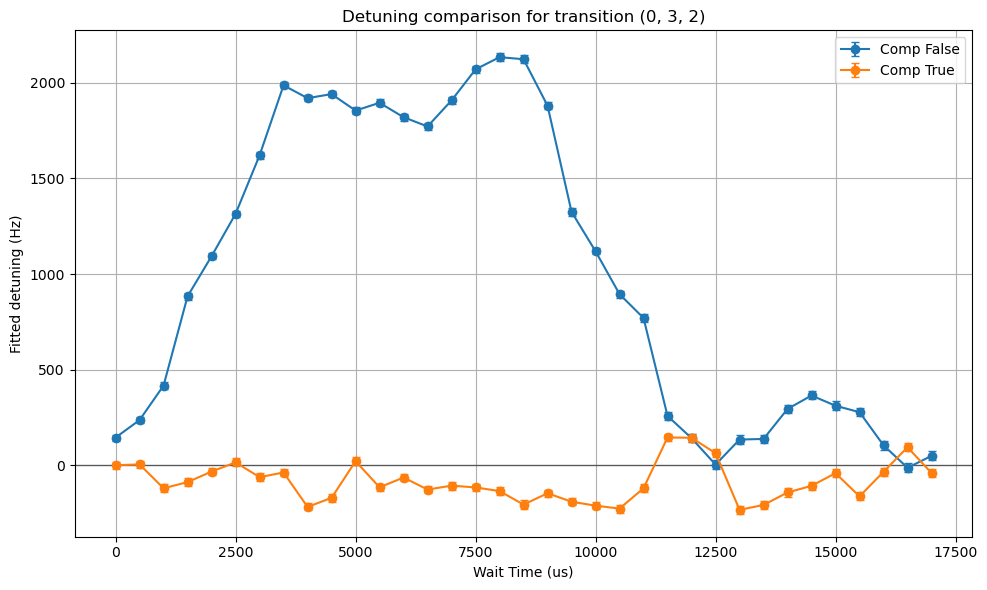

<Axes: title={'center': 'Detuning comparison for transition (0, 3, 2)'}, xlabel='Wait Time (us)', ylabel='Fitted detuning (Hz)'>

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def plot_detuning_comparison_by_comp(detuning_fit_results_by_comp):
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = {False: "C0", True: "C1"}
    plotted_any = False

    for comp_flag in (False, True):
        result = detuning_fit_results_by_comp.get(comp_flag, {})
        wait_times = np.array(result.get("fit_wait_times_list", []), dtype=float)
        detunings = np.array(
            [np.nan if d is None else d for d in result.get("fit_detunings_list", [])],
            dtype=float,
        )
        detuning_errors = np.array(
            [np.nan if e is None else e for e in result.get("fit_detuning_errors_list", [])],
            dtype=float,
        )

        valid = np.isfinite(wait_times) & np.isfinite(detunings)
        if not np.any(valid):
            print(f"Comp {comp_flag}: no finite detuning points for comparison plot.")
            continue

        wait_times = wait_times[valid]
        detunings_hz = detunings[valid] / (2 * np.pi)
        detuning_errors_hz = detuning_errors[valid] / (2 * np.pi)

        order = np.argsort(wait_times)
        wait_times = wait_times[order]
        detunings_hz = detunings_hz[order]
        detuning_errors_hz = detuning_errors_hz[order]

        yerr = np.where(np.isfinite(detuning_errors_hz), detuning_errors_hz, 0.0)
        ax.errorbar(
            wait_times,
            detunings_hz,
            yerr=yerr,
            fmt="o-",
            capsize=3,
            color=colors[comp_flag],
            ecolor=colors[comp_flag],
            label=f"Comp {comp_flag}",
        )
        plotted_any = True

    if not plotted_any:
        return None

    ax.axhline(0.0, color="black", linewidth=1.0, alpha=0.5)
    ax.set_xlabel("Wait Time (us)")
    ax.set_ylabel("Fitted detuning (Hz)")
    ax.set_title(f"Detuning comparison for transition {target_transition}")
    ax.grid()
    ax.legend()
    plt.tight_layout()
    plt.savefig("detuning_comparison_comp_false_true.png", dpi=300)
    plt.show()
    return ax


plot_detuning_comparison_by_comp(detuning_fit_results_by_comp)



Detuning compensation summary

Compensation OFF
  N points              = 35
  Mean detuning         = 1005.606 Hz
  RMS detuning          = 1275.430 Hz
  AC RMS detuning       = 784.525 Hz   (mean removed)
  Peak-to-peak detuning = 2146.956 Hz
  Max |detuning|        = 2134.240 Hz
  Weighted RMS          = 1341.384 Hz
  Weighted AC RMS       = 762.627 Hz

Compensation ON
  N points              = 35
  Mean detuning         = -84.651 Hz
  RMS detuning          = 131.510 Hz
  AC RMS detuning       = 100.643 Hz   (mean removed)
  Peak-to-peak detuning = 378.331 Hz
  Max |detuning|        = 232.541 Hz
  Weighted RMS          = 132.170 Hz
  Weighted AC RMS       = 101.403 Hz

Suppression factors
  RMS suppression          = 9.70x
  AC RMS suppression       = 7.80x
  Peak-to-peak suppression = 5.67x
  Max |detuning| suppression = 9.18x

Fractional reduction
  RMS reduction          = 89.7%
  AC RMS reduction       = 87.2%
  Peak-to-peak reduction = 82.4%
  Weighted RMS suppression    = 10.

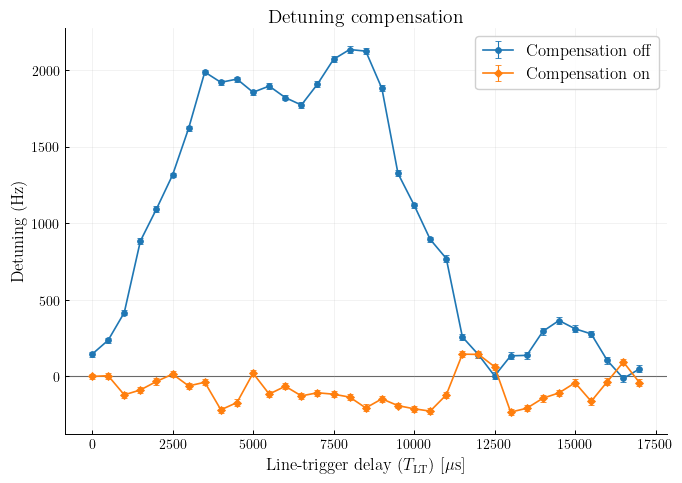

(<Axes: title={'center': 'Detuning compensation'}, xlabel='Line-trigger delay ($T_{\\mathrm{LT}}$) [$\\mu$s]', ylabel='Detuning (Hz)'>,
 {False: {'mean_hz': np.float64(1005.6056145618763),
   'rms_hz': np.float64(1275.4299194328055),
   'ac_rms_hz': np.float64(784.5245868333282),
   'peak_to_peak_hz': np.float64(2146.955846541405),
   'max_abs_hz': np.float64(2134.2400304869175),
   'n_points': 35,
   'weighted_mean_hz': np.float64(1103.499329516436),
   'weighted_rms_hz': np.float64(1341.3840958535893),
   'weighted_ac_rms_hz': np.float64(762.6273810752716)},
  True: {'mean_hz': np.float64(-84.6507030568502),
   'rms_hz': np.float64(131.50961639076812),
   'ac_rms_hz': np.float64(100.64312035717077),
   'peak_to_peak_hz': np.float64(378.33127888343597),
   'max_abs_hz': np.float64(232.54076330066826),
   'n_points': 35,
   'weighted_mean_hz': np.float64(-84.77176358658127),
   'weighted_rms_hz': np.float64(132.16958702409093),
   'weighted_ac_rms_hz': np.float64(101.4028985411143)}})

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# =========================================================
# NATURE-STYLE PLOT SETTINGS
# =========================================================
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
rcParams['figure.figsize'] = (8, 8)

rcParams.update({
    # "font.family": "sans-serif",
    # "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    # "text.usetex": False,
    # "mathtext.fontset": "dejavusans",

    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 12,

    "axes.linewidth": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,

    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def plot_detuning_comparison_by_comp(detuning_fit_results_by_comp):
    fig, ax = plt.subplots(figsize=(7, 5))

    colors = {
        False: "C0",
        True: "C1",
    }

    labels = {
        False: "Compensation off",
        True: "Compensation on",
    }

    markers = {
        False: "o",
        True: "D",
    }

    plotted_any = False

    for comp_flag in (False, True):
        result = detuning_fit_results_by_comp.get(comp_flag, {})

        wait_times = np.array(result.get("fit_wait_times_list", []), dtype=float)

        detunings = np.array(
            [np.nan if d is None else d for d in result.get("fit_detunings_list", [])],
            dtype=float,
        )

        detuning_errors = np.array(
            [np.nan if e is None else e for e in result.get("fit_detuning_errors_list", [])],
            dtype=float,
        )

        valid = np.isfinite(wait_times) & np.isfinite(detunings)

        if not np.any(valid):
            print(f"Comp {comp_flag}: no finite detuning points for comparison plot.")
            continue

        wait_times = wait_times[valid]
        detunings_hz = detunings[valid] / (2 * np.pi)
        detuning_errors_hz = detuning_errors[valid] / (2 * np.pi)

        order = np.argsort(wait_times)
        wait_times = wait_times[order]
        detunings_hz = detunings_hz[order]
        detuning_errors_hz = detuning_errors_hz[order]

        yerr = np.where(np.isfinite(detuning_errors_hz), detuning_errors_hz, 0.0)

        ax.errorbar(
            wait_times,
            detunings_hz,
            yerr=yerr,
            fmt=markers[comp_flag],
            markersize=4.2,
            linestyle="-",
            linewidth=1.2,
            capsize=2.5,
            elinewidth=0.8,
            markeredgewidth=0.6,
            color=colors[comp_flag],
            ecolor=colors[comp_flag],
            label=labels[comp_flag],
            zorder=3,
        )

        plotted_any = True

    if not plotted_any:
        return None

    ax.axhline(
        0.0,
        color="0.2",
        linewidth=0.8,
        alpha=0.8,
        zorder=1,
    )

    ax.set_xlabel(r"Line-trigger delay ($T_{\mathrm{LT}}$) [$\mu$s]")
    ax.set_ylabel("Detuning (Hz)")
    ax.set_title("Detuning compensation", pad=4)

    ax.grid(True, which="major", linewidth=0.45, alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="best",
        frameon=True,
        framealpha=0.92,
        borderpad=0.45,
        handlelength=1.8,
    )

    fig.tight_layout()

    fig.savefig("detuning_compensation_nature_style.svg", bbox_inches="tight")
    fig.savefig("detuning_compensation_nature_style.pdf", bbox_inches="tight")
    fig.savefig("detuning_compensation_nature_style.png", dpi=600, bbox_inches="tight")

    plt.show()

    return ax

def compute_detuning_metrics(detunings_hz, detuning_errors_hz=None):
    detunings_hz = np.asarray(detunings_hz, dtype=float)
    valid = np.isfinite(detunings_hz)
    detunings_hz = detunings_hz[valid]

    if detunings_hz.size == 0:
        return None

    mean = np.mean(detunings_hz)
    rms = np.sqrt(np.mean(detunings_hz**2))
    ac_rms = np.sqrt(np.mean((detunings_hz - mean)**2))
    peak_to_peak = np.max(detunings_hz) - np.min(detunings_hz)
    max_abs = np.max(np.abs(detunings_hz))

    metrics = {
        "mean_hz": mean,
        "rms_hz": rms,
        "ac_rms_hz": ac_rms,
        "peak_to_peak_hz": peak_to_peak,
        "max_abs_hz": max_abs,
        "n_points": detunings_hz.size,
    }

    # Weighted metrics, if finite nonzero uncertainties are available
    if detuning_errors_hz is not None:
        detuning_errors_hz = np.asarray(detuning_errors_hz, dtype=float)[valid]
        w_valid = np.isfinite(detuning_errors_hz) & (detuning_errors_hz > 0)

        if np.any(w_valid):
            y = detunings_hz[w_valid]
            sigma = detuning_errors_hz[w_valid]
            w = 1.0 / sigma**2

            w_mean = np.sum(w * y) / np.sum(w)
            w_rms = np.sqrt(np.sum(w * y**2) / np.sum(w))
            w_ac_rms = np.sqrt(np.sum(w * (y - w_mean)**2) / np.sum(w))

            metrics.update({
                "weighted_mean_hz": w_mean,
                "weighted_rms_hz": w_rms,
                "weighted_ac_rms_hz": w_ac_rms,
            })

    return metrics


def print_detuning_compensation_summary(metrics_by_comp):
    off = metrics_by_comp.get(False)
    on = metrics_by_comp.get(True)

    print("\n" + "=" * 72)
    print("Detuning compensation summary")
    print("=" * 72)

    for comp_flag, name in [(False, "Compensation OFF"), (True, "Compensation ON")]:
        m = metrics_by_comp.get(comp_flag)
        if m is None:
            print(f"{name}: no valid data")
            continue

        print(f"\n{name}")
        print(f"  N points              = {m['n_points']}")
        print(f"  Mean detuning         = {m['mean_hz']:.3f} Hz")
        print(f"  RMS detuning          = {m['rms_hz']:.3f} Hz")
        print(f"  AC RMS detuning       = {m['ac_rms_hz']:.3f} Hz   (mean removed)")
        print(f"  Peak-to-peak detuning = {m['peak_to_peak_hz']:.3f} Hz")
        print(f"  Max |detuning|        = {m['max_abs_hz']:.3f} Hz")

        if "weighted_rms_hz" in m:
            print(f"  Weighted RMS          = {m['weighted_rms_hz']:.3f} Hz")
            print(f"  Weighted AC RMS       = {m['weighted_ac_rms_hz']:.3f} Hz")

    if off is not None and on is not None:
        print("\nSuppression factors")
        print(f"  RMS suppression          = {off['rms_hz'] / on['rms_hz']:.2f}x")
        print(f"  AC RMS suppression       = {off['ac_rms_hz'] / on['ac_rms_hz']:.2f}x")
        print(f"  Peak-to-peak suppression = {off['peak_to_peak_hz'] / on['peak_to_peak_hz']:.2f}x")
        print(f"  Max |detuning| suppression = {off['max_abs_hz'] / on['max_abs_hz']:.2f}x")

        print("\nFractional reduction")
        print(f"  RMS reduction          = {100 * (1 - on['rms_hz'] / off['rms_hz']):.1f}%")
        print(f"  AC RMS reduction       = {100 * (1 - on['ac_rms_hz'] / off['ac_rms_hz']):.1f}%")
        print(f"  Peak-to-peak reduction = {100 * (1 - on['peak_to_peak_hz'] / off['peak_to_peak_hz']):.1f}%")

        if "weighted_rms_hz" in off and "weighted_rms_hz" in on:
            print(f"  Weighted RMS suppression    = {off['weighted_rms_hz'] / on['weighted_rms_hz']:.2f}x")
            print(f"  Weighted AC RMS suppression = {off['weighted_ac_rms_hz'] / on['weighted_ac_rms_hz']:.2f}x")

    print("=" * 72 + "\n")


def plot_detuning_comparison_by_comp(detuning_fit_results_by_comp):
    fig, ax = plt.subplots(figsize=(7, 5))

    colors = {
        False: "C0",
        True: "C1",
    }

    labels = {
        False: "Compensation off",
        True: "Compensation on",
    }

    markers = {
        False: "o",
        True: "D",
    }

    plotted_any = False
    metrics_by_comp = {}

    for comp_flag in (False, True):
        result = detuning_fit_results_by_comp.get(comp_flag, {})

        wait_times = np.array(result.get("fit_wait_times_list", []), dtype=float)

        detunings = np.array(
            [np.nan if d is None else d for d in result.get("fit_detunings_list", [])],
            dtype=float,
        )

        detuning_errors = np.array(
            [np.nan if e is None else e for e in result.get("fit_detuning_errors_list", [])],
            dtype=float,
        )

        valid = np.isfinite(wait_times) & np.isfinite(detunings)

        if not np.any(valid):
            print(f"Comp {comp_flag}: no finite detuning points for comparison plot.")
            metrics_by_comp[comp_flag] = None
            continue

        wait_times = wait_times[valid]
        detunings_hz = detunings[valid] / (2 * np.pi)
        detuning_errors_hz = detuning_errors[valid] / (2 * np.pi)

        order = np.argsort(wait_times)
        wait_times = wait_times[order]
        detunings_hz = detunings_hz[order]
        detuning_errors_hz = detuning_errors_hz[order]

        # Store metrics for printing
        metrics_by_comp[comp_flag] = compute_detuning_metrics(
            detunings_hz,
            detuning_errors_hz,
        )

        yerr = np.where(np.isfinite(detuning_errors_hz), detuning_errors_hz, 0.0)

        ax.errorbar(
            wait_times,
            detunings_hz,
            yerr=yerr,
            fmt=markers[comp_flag],
            markersize=4.2,
            linestyle="-",
            linewidth=1.2,
            capsize=2.5,
            elinewidth=0.8,
            markeredgewidth=0.6,
            color=colors[comp_flag],
            ecolor=colors[comp_flag],
            label=labels[comp_flag],
            zorder=3,
        )

        plotted_any = True

    if not plotted_any:
        return None

    # Print quantitative compensation metrics
    print_detuning_compensation_summary(metrics_by_comp)

    ax.axhline(
        0.0,
        color="0.2",
        linewidth=0.8,
        alpha=0.8,
        zorder=1,
    )

    ax.set_xlabel(r"Line-trigger delay ($T_{\mathrm{LT}}$) [$\mu$s]")
    ax.set_ylabel("Detuning (Hz)")
    ax.set_title("Detuning compensation", pad=4)

    ax.grid(True, which="major", linewidth=0.45, alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="best",
        frameon=True,
        framealpha=0.92,
        borderpad=0.45,
        handlelength=1.8,
    )

    fig.tight_layout()

    fig.savefig("detuning_compensation_nature_style.svg", bbox_inches="tight")
    fig.savefig("detuning_compensation_nature_style.pdf", bbox_inches="tight")
    fig.savefig("detuning_compensation_nature_style.png", dpi=600, bbox_inches="tight")

    plt.show()

    return ax, metrics_by_comp


# ax, detuning_metrics_by_comp = plot_detuning_comparison_by_comp(detuning_fit_results_by_comp)

plot_detuning_comparison_by_comp(detuning_fit_results_by_comp)

# paper figure - detuning comp


Detuning compensation: structured-signal metrics
Calibrated AC file: line_signal_fit_params_20260514_K10.txt
Transition sensitivity: 3.20153 MHz/G
Harmonic basis: first 10 harmonics of 60.0 Hz
Matched-filter model: detuning(t) = b + a_AC f_AC(t)

Compensation OFF
  N points                         = 35
  Harmonic fit degrees of freedom  = 14
  Harmonic amplitude A_AC          = 1093.859 +/- 17.217 Hz
  Matched-filter scale a_AC        = 0.98216 +/- 0.01784
  Matched-filter offset b          = 1050.173 +/- 13.809 Hz
  Correlation with AC waveform     = 0.9946 +/- 0.0019

Compensation ON
  N points                         = 35
  Harmonic fit degrees of freedom  = 14
  Harmonic amplitude A_AC          = 131.523 +/- 13.212 Hz
  Matched-filter scale a_AC        = -0.04772 +/- 0.02084
  Matched-filter offset b          = -85.344 +/- 16.399 Hz
  Correlation with AC waveform     = -0.3575 +/- 0.1542

Suppression metrics
  Harmonic-amplitude suppression   = 8.32 +/- 0.85x
  Matched-filter supp

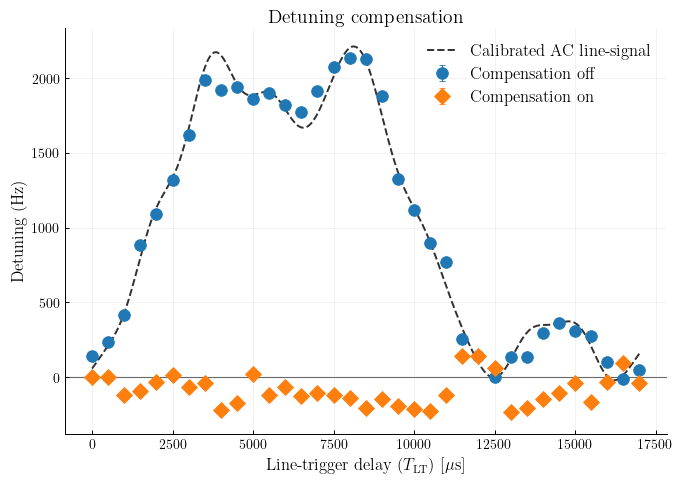

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from pathlib import Path

# =========================================================
# NATURE-STYLE PLOT SETTINGS
# =========================================================
rcParams["font.family"] = "serif"
rcParams["font.serif"] = ["Computer Modern"]
rcParams["text.usetex"] = True
rcParams["figure.figsize"] = (8, 8)

rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 12,

    "axes.linewidth": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,

    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# USER OPTIONS
# =========================================================
LINE_SIGNAL_FIT_FILE = "line_signal_fit_params_20260514_K10.txt"

# Sensitivity of the transition used in the detuning-compensation experiment.
# Units: MHz/G.
# Hz from mG is: sensitivity_MHz_per_G * 1000 * B_mG.
TEST_TRANSITION_SENSITIVITY_MHZ_PER_G = 3.20153

LINE_FREQ_HZ = 60.0
HARMONIC_K = 10

# Plot calibrated template on the detuning figure.
SHOW_CALIBRATED_TEMPLATE = True

# "unit_scale": plot calibrated template with a = 1 and fitted offset from comp-off data.
# "projection_off": plot best template projection onto comp-off data, b + a f_LS(t).
TEMPLATE_PLOT_MODE = "unit_scale"


# =========================================================
# CALIBRATED LINE-SIGNAL TEMPLATE
# =========================================================
def load_line_signal_fit_params(filename):
    """
    Load line_signal_fit_params_*.txt.

    Expected format:
        # B0 B0_err (mG)
        B0 B0_err
        # f_Hz A A_err phi phi_err
        f_Hz A A_err phi phi_err
        ...

    Returns a dict with B0 and harmonic parameters.
    """
    path = Path(filename)

    if not path.exists():
        raise FileNotFoundError(
            f"Could not find {filename!r}. Put it in the current working directory "
            "or set LINE_SIGNAL_FIT_FILE to the full path."
        )

    numeric_rows = []

    with open(path, "r") as f:
        for line in f:
            line = line.strip()

            if not line or line.startswith("#"):
                continue

            values = [float(x) for x in line.split()]
            numeric_rows.append(values)

    if len(numeric_rows) < 2:
        raise ValueError(f"{filename!r} does not contain enough numeric rows.")

    B0_fit = numeric_rows[0][0]
    B0_err = numeric_rows[0][1] if len(numeric_rows[0]) > 1 else np.nan

    harmonic_rows = numeric_rows[1:]

    harmonics = []
    for row in harmonic_rows:
        if len(row) < 5:
            raise ValueError(
                "Each harmonic row must contain: f_Hz A A_err phi phi_err"
            )

        f_hz, A_mG, A_err_mG, phi_rad, phi_err_rad = row[:5]

        harmonics.append({
            "f_hz": f_hz,
            "A_mG": A_mG,
            "A_err_mG": A_err_mG,
            "phi_rad": phi_rad,
            "phi_err_rad": phi_err_rad,
        })

    return {
        "filename": str(path),
        "B0_mG": B0_fit,
        "B0_err_mG": B0_err,
        "harmonics": harmonics,
    }

def total_harmonic_amplitude_error(params, covariance, start_index=1):
    """
    Uncertainty of A_AC = sqrt(sum q_i^2), where q_i are the fitted
    harmonic sine/cosine coefficients.

    Detuning model:
        params = [c0, a1, b1, a2, b2, ...]
        start_index = 1
    """
    params = np.asarray(params, dtype=float)

    if covariance is None or not np.all(np.isfinite(covariance)):
        return np.nan

    q = params[start_index:]
    A_total = np.sqrt(np.sum(q**2))

    if A_total <= 0:
        return np.nan

    grad = np.zeros_like(params, dtype=float)
    grad[start_index:] = q / A_total

    variance = grad @ covariance @ grad
    return np.sqrt(max(variance, 0.0))


def correlation_error_fisher(rho, n_points):
    """
    Approximate uncertainty of Pearson correlation coefficient using the
    Fisher transform.
    """
    if not np.isfinite(rho) or n_points <= 3:
        return np.nan

    sigma_z = 1.0 / np.sqrt(n_points - 3)
    sigma_rho = (1.0 - rho**2) * sigma_z

    return sigma_rho


def ratio_with_error(x_off, sx_off, x_on, sx_on):
    """
    Propagate uncertainty for S = |x_off| / |x_on|.
    """
    if not np.isfinite(x_off) or not np.isfinite(x_on) or x_on == 0:
        return np.nan, np.nan

    S = abs(x_off) / abs(x_on)

    if not np.isfinite(sx_off) or not np.isfinite(sx_on):
        return S, np.nan

    relative_variance = (sx_off / x_off)**2 + (sx_on / x_on)**2
    S_err = S * np.sqrt(relative_variance)

    return S, S_err

def evaluate_calibrated_B_template_mG(t_us, calibration, include_offset=False):
    """
    Evaluate calibrated line-synchronous B-field waveform in mG.

    By default include_offset=False, because the constant B0 is not part of
    the structured line-synchronous component. Static offsets are handled by
    the fitted intercept in the template projection.
    """
    t_s = np.asarray(t_us, dtype=float) * 1e-6

    if include_offset:
        y_mG = np.full_like(t_s, calibration["B0_mG"], dtype=float)
    else:
        y_mG = np.zeros_like(t_s, dtype=float)

    for h in calibration["harmonics"]:
        y_mG += h["A_mG"] * np.cos(
            2.0 * np.pi * h["f_hz"] * t_s + h["phi_rad"]
        )

    return y_mG


def evaluate_calibrated_detuning_template_hz(
    t_us,
    calibration,
    sensitivity_MHz_per_G,
):
    """
    Convert calibrated B-field template to detuning in Hz.

    B_mG -> G: B_mG * 1e-3
    MHz/G -> Hz/G: sensitivity * 1e6
    Therefore detuning_Hz = sensitivity_MHz_per_G * 1000 * B_mG.
    """
    B_template_mG = evaluate_calibrated_B_template_mG(
        t_us,
        calibration,
        include_offset=False,
    )

    return sensitivity_MHz_per_G * 1000.0 * B_template_mG


# =========================================================
# HARMONIC-POWER METRIC
# =========================================================
def harmonic_design_matrix(t_us, K=10, line_freq_hz=60.0):
    """
    Linear harmonic model:
        y(t) = c0 + sum_n [a_n cos(2 pi n f_line t) + b_n sin(2 pi n f_line t)]

    t_us is in microseconds.
    """
    t_s = np.asarray(t_us, dtype=float) * 1e-6

    columns = [np.ones_like(t_s)]

    for n in range(1, K + 1):
        omega_t = 2.0 * np.pi * n * line_freq_hz * t_s
        columns.append(np.cos(omega_t))
        columns.append(np.sin(omega_t))

    return np.column_stack(columns)


def evaluate_harmonic_model(t_us, params, line_freq_hz=60.0):
    K = (len(params) - 1) // 2
    X = harmonic_design_matrix(t_us, K=K, line_freq_hz=line_freq_hz)
    return X @ params

def fit_harmonic_model(t_us, y_hz, yerr_hz=None, K=10, line_freq_hz=60.0):
    """
    Fit harmonic basis to detuning data and compute total harmonic amplitude:
        A_AC = sqrt(sum_n A_n^2)
    where A_n = sqrt(a_n^2 + b_n^2).
    """
    t_us = np.asarray(t_us, dtype=float)
    y_hz = np.asarray(y_hz, dtype=float)

    valid = np.isfinite(t_us) & np.isfinite(y_hz)

    if yerr_hz is not None:
        yerr_hz = np.asarray(yerr_hz, dtype=float)
        valid &= np.isfinite(yerr_hz) & (yerr_hz > 0)

    t_fit = t_us[valid]
    y_fit = y_hz[valid]
    sigma = yerr_hz[valid] if yerr_hz is not None else None

    n_points = len(y_fit)
    n_params = 2 * K + 1
    dof = n_points - n_params

    if dof <= 0:
        raise ValueError(
            f"Not enough data points for K={K}: "
            f"N={n_points}, parameters={n_params}."
        )

    X = harmonic_design_matrix(t_fit, K=K, line_freq_hz=line_freq_hz)

    use_weights = sigma is not None and np.all(np.isfinite(sigma)) and np.all(sigma > 0)

    if use_weights:
        Xw = X / sigma[:, None]
        yw = y_fit / sigma

        params, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
        y_model = X @ params
        residual = y_fit - y_model

        chi2 = np.sum((residual / sigma) ** 2)
        reduced_chi2 = chi2 / dof

        covariance = np.linalg.pinv(Xw.T @ Xw) * reduced_chi2

    else:
        params, *_ = np.linalg.lstsq(X, y_fit, rcond=None)
        y_model = X @ params
        residual = y_fit - y_model

        residual_variance = np.sum(residual**2) / dof
        reduced_chi2 = np.nan

        covariance = np.linalg.pinv(X.T @ X) * residual_variance

    a_coeffs = params[1::2]
    b_coeffs = params[2::2]
    amplitudes = np.sqrt(a_coeffs**2 + b_coeffs**2)

    harmonic_amplitude_norm_hz = np.sqrt(np.sum(amplitudes**2))
    harmonic_amplitude_norm_err_hz = total_harmonic_amplitude_error(
        params,
        covariance,
        start_index=1,
    )

    harmonic_structured_rms_hz = harmonic_amplitude_norm_hz / np.sqrt(2.0)

    return {
        "K": K,
        "t_us": t_fit,
        "y_hz": y_fit,
        "params": params,
        "covariance": covariance,
        "y_model_hz": y_model,
        "residual_hz": residual,
        "amplitudes_hz": amplitudes,
        "harmonic_amplitude_norm_hz": harmonic_amplitude_norm_hz,
        "harmonic_amplitude_norm_err_hz": harmonic_amplitude_norm_err_hz,
        "harmonic_structured_rms_hz": harmonic_structured_rms_hz,
        "offset_hz": params[0],
        "n_points": n_points,
        "n_params": n_params,
        "dof": dof,
        "reduced_chi2": reduced_chi2,
    }

# =========================================================
# MATCHED-FILTER / TEMPLATE-PROJECTION METRIC
# =========================================================
def template_projection(y_hz, template_hz, yerr_hz=None):
    """
    Fit:
        y_hz = b + a * template_hz

    a is the residual line-synchronous template amplitude.
    b is a static offset.
    """
    y_hz = np.asarray(y_hz, dtype=float)
    template_hz = np.asarray(template_hz, dtype=float)

    valid = np.isfinite(y_hz) & np.isfinite(template_hz)

    y = y_hz[valid]
    template = template_hz[valid]

    X = np.column_stack([np.ones_like(template), template])

    use_weights = False

    if yerr_hz is not None:
        sigma = np.asarray(yerr_hz, dtype=float)[valid]

        if np.all(np.isfinite(sigma)) and np.all(sigma > 0):
            use_weights = True

    if use_weights:
        Xw = X / sigma[:, None]
        yw = y / sigma
        coeffs, *_ = np.linalg.lstsq(Xw, yw, rcond=None)

        residual = y - X @ coeffs
        dof = len(y) - X.shape[1]
        chi2 = np.sum((residual / sigma) ** 2)
        red_chi2 = chi2 / dof if dof > 0 else np.nan

        cov = np.linalg.pinv(Xw.T @ Xw)
        if np.isfinite(red_chi2):
            cov = cov * red_chi2

    else:
        coeffs, *_ = np.linalg.lstsq(X, y, rcond=None)

        residual = y - X @ coeffs
        dof = len(y) - X.shape[1]
        red_chi2 = np.nan

        residual_var = np.sum(residual**2) / dof if dof > 0 else np.nan
        cov = np.linalg.pinv(X.T @ X)
        if np.isfinite(residual_var):
            cov = cov * residual_var

    offset = coeffs[0]
    scale = coeffs[1]

    if cov is not None and np.all(np.isfinite(cov)):
        offset_err = np.sqrt(max(cov[0, 0], 0.0))
        scale_err = np.sqrt(max(cov[1, 1], 0.0))
    else:
        offset_err = np.nan
        scale_err = np.nan

    y_fit_full = np.full_like(y_hz, np.nan, dtype=float)
    y_fit_full[valid] = offset + scale * template

    return {
        "scale": scale,
        "scale_err": scale_err,
        "offset_hz": offset,
        "offset_err_hz": offset_err,
        "fit_hz": y_fit_full,
        "dof": dof,
        "reduced_chi2": red_chi2,
    }


def pearson_correlation(y_hz, template_hz):
    """
    Correlation with the calibrated template after mean subtraction.
    This is supporting information only; template scale is the main metric.
    """
    y_hz = np.asarray(y_hz, dtype=float)
    template_hz = np.asarray(template_hz, dtype=float)

    valid = np.isfinite(y_hz) & np.isfinite(template_hz)

    y = y_hz[valid]
    template = template_hz[valid]

    y0 = y - np.mean(y)
    t0 = template - np.mean(template)

    denom = np.sqrt(np.sum(y0**2) * np.sum(t0**2))

    if denom == 0:
        return np.nan

    return np.sum(y0 * t0) / denom


# =========================================================
# DATA EXTRACTION
# =========================================================
def extract_detuning_data_by_comp(detuning_fit_results_by_comp):
    """
    Convert detuning_fit_results_by_comp into sorted arrays in Hz.
    """
    data_by_comp = {}

    for comp_flag in (False, True):
        result = detuning_fit_results_by_comp.get(comp_flag, {})

        wait_times = np.array(result.get("fit_wait_times_list", []), dtype=float)

        detunings = np.array(
            [np.nan if d is None else d for d in result.get("fit_detunings_list", [])],
            dtype=float,
        )

        detuning_errors = np.array(
            [np.nan if e is None else e for e in result.get("fit_detuning_errors_list", [])],
            dtype=float,
        )

        valid = np.isfinite(wait_times) & np.isfinite(detunings)

        if not np.any(valid):
            print(f"Comp {comp_flag}: no finite detuning points.")
            data_by_comp[comp_flag] = None
            continue

        wait_times = wait_times[valid]
        detunings_hz = detunings[valid] / (2 * np.pi)
        detuning_errors_hz = detuning_errors[valid] / (2 * np.pi)

        order = np.argsort(wait_times)

        data_by_comp[comp_flag] = {
            "wait_times_us": wait_times[order],
            "detunings_hz": detunings_hz[order],
            "detuning_errors_hz": detuning_errors_hz[order],
        }

    return data_by_comp


# =========================================================
# METRICS
# =========================================================
def compute_compensation_metrics(data_by_comp, calibration):
    """
    Compute:
      1. Harmonic amplitude suppression from direct harmonic fits.
      2. Matched-filter projection using calibrated line signal.
      3. Correlation with calibrated AC waveform.
    """
    metrics_by_comp = {}

    for comp_flag in (False, True):
        data = data_by_comp.get(comp_flag)

        if data is None:
            metrics_by_comp[comp_flag] = None
            continue

        wait_times = data["wait_times_us"]
        y_hz = data["detunings_hz"]
        yerr_hz = data["detuning_errors_hz"]

        harmonic_fit = fit_harmonic_model(
            wait_times,
            y_hz,
            yerr_hz=yerr_hz,
            K=HARMONIC_K,
            line_freq_hz=LINE_FREQ_HZ,
        )

        template_hz = evaluate_calibrated_detuning_template_hz(
            wait_times,
            calibration,
            TEST_TRANSITION_SENSITIVITY_MHZ_PER_G,
        )

        projection = template_projection(
            y_hz,
            template_hz,
            yerr_hz=yerr_hz,
        )

        rho = pearson_correlation(y_hz, template_hz)
        rho_err = correlation_error_fisher(
            rho,
            n_points=len(y_hz),
        )

        metrics_by_comp[comp_flag] = {
            "harmonic_fit": harmonic_fit,
            "template_hz": template_hz,
            "projection": projection,
            "correlation_with_template": rho,
            "correlation_err": rho_err,
        }

    return metrics_by_comp
def print_compensation_summary(metrics_by_comp, calibration):
    off = metrics_by_comp.get(False)
    on = metrics_by_comp.get(True)

    print("\n" + "=" * 92)
    print("Detuning compensation: structured-signal metrics")
    print("=" * 92)
    print(f"Calibrated AC file: {calibration['filename']}")
    print(f"Transition sensitivity: {TEST_TRANSITION_SENSITIVITY_MHZ_PER_G:.6g} MHz/G")
    print(f"Harmonic basis: first {HARMONIC_K} harmonics of {LINE_FREQ_HZ:.1f} Hz")
    print("Matched-filter model: detuning(t) = b + a_AC f_AC(t)")

    for comp_flag, name in [(False, "Compensation OFF"), (True, "Compensation ON")]:
        m = metrics_by_comp.get(comp_flag)

        if m is None:
            print(f"\n{name}: no valid data")
            continue

        hfit = m["harmonic_fit"]
        proj = m["projection"]

        print(f"\n{name}")
        print(f"  N points                         = {hfit['n_points']}")
        print(f"  Harmonic fit degrees of freedom  = {hfit['dof']}")
        print(
            f"  Harmonic amplitude A_AC          = "
            f"{hfit['harmonic_amplitude_norm_hz']:.3f} +/- "
            f"{hfit['harmonic_amplitude_norm_err_hz']:.3f} Hz"
        )
        print(
            f"  Matched-filter scale a_AC        = "
            f"{proj['scale']:.5f} +/- {proj['scale_err']:.5f}"
        )
        print(
            f"  Matched-filter offset b          = "
            f"{proj['offset_hz']:.3f} +/- {proj['offset_err_hz']:.3f} Hz"
        )
        print(
            f"  Correlation with AC waveform     = "
            f"{m['correlation_with_template']:.4f} +/- {m['correlation_err']:.4f}"
        )

    if off is not None and on is not None:
        h_off = off["harmonic_fit"]
        h_on = on["harmonic_fit"]

        A_off = h_off["harmonic_amplitude_norm_hz"]
        A_on = h_on["harmonic_amplitude_norm_hz"]
        A_off_err = h_off["harmonic_amplitude_norm_err_hz"]
        A_on_err = h_on["harmonic_amplitude_norm_err_hz"]

        a_off = off["projection"]["scale"]
        a_on = on["projection"]["scale"]
        a_off_err = off["projection"]["scale_err"]
        a_on_err = on["projection"]["scale_err"]

        S_A, S_A_err = ratio_with_error(A_off, A_off_err, A_on, A_on_err)
        S_a, S_a_err = ratio_with_error(a_off, a_off_err, a_on, a_on_err)

        print("\nSuppression metrics")
        print(
            f"  Harmonic-amplitude suppression   = "
            f"{S_A:.2f} +/- {S_A_err:.2f}x"
        )

        if abs(a_on) <= 2 * a_on_err:
            print(
                f"  Matched-filter suppression       = "
                f"{S_a:.2f}x central value"
            )
            print(
                "                                      compensated fitted amplitude is close to zero"
            )
        else:
            print(
                f"  Matched-filter suppression       = "
                f"{S_a:.2f} +/- {S_a_err:.2f}x"
            )

        print(
            f"  Matched-filter scale off -> on   = "
            f"{a_off:.5f} +/- {a_off_err:.5f} -> "
            f"{a_on:.5f} +/- {a_on_err:.5f}"
        )
        print(
            f"  Correlation off -> on            = "
            f"{off['correlation_with_template']:.4f} +/- {off['correlation_err']:.4f} -> "
            f"{on['correlation_with_template']:.4f} +/- {on['correlation_err']:.4f}"
        )

    print("=" * 92 + "\n")

# =========================================================
# PLOT
# =========================================================
def plot_detuning_comparison_by_comp(detuning_fit_results_by_comp):
    calibration = load_line_signal_fit_params(LINE_SIGNAL_FIT_FILE)

    fig, ax = plt.subplots(figsize=(7, 5))

    colors = {
        False: "C0",
        True: "C1",
    }

    labels = {
        False: "Compensation off",
        True: "Compensation on",
    }

    markers = {
        False: "o",
        True: "D",
    }

    data_by_comp = extract_detuning_data_by_comp(detuning_fit_results_by_comp)

    plotted_any = False

    for comp_flag in (False, True):
        data = data_by_comp.get(comp_flag)

        if data is None:
            continue

        wait_times = data["wait_times_us"]
        detunings_hz = data["detunings_hz"]
        detuning_errors_hz = data["detuning_errors_hz"]

        yerr = np.where(np.isfinite(detuning_errors_hz), detuning_errors_hz, 0.0)

        ax.errorbar(
            wait_times,
            detunings_hz,
            yerr=yerr,
            fmt=markers[comp_flag],
            markersize=8.4,
            # linestyle="-",
            # linewidth=1.2,
            capsize=2.5,
            elinewidth=0.8,
            markeredgewidth=0.6,
            color=colors[comp_flag],
            ecolor=colors[comp_flag],
            label=labels[comp_flag],
            zorder=3,
        )

        plotted_any = True

    if not plotted_any:
        return None

    metrics_by_comp = compute_compensation_metrics(data_by_comp, calibration)

    print_compensation_summary(metrics_by_comp, calibration)

    # ---------------------------------------------------------
    # Plot calibrated line-signal template
    # ---------------------------------------------------------
    if SHOW_CALIBRATED_TEMPLATE:
        valid_data = [
            data for data in data_by_comp.values()
            if data is not None
        ]

        t_min = min(np.min(data["wait_times_us"]) for data in valid_data)
        t_max = max(np.max(data["wait_times_us"]) for data in valid_data)

        t_template_us = np.linspace(t_min, t_max, 1500)

        template_hz = evaluate_calibrated_detuning_template_hz(
            t_template_us,
            calibration,
            TEST_TRANSITION_SENSITIVITY_MHZ_PER_G,
        )

        off_projection = metrics_by_comp[False]["projection"]

        if TEMPLATE_PLOT_MODE == "unit_scale":
            y_template_plot = off_projection["offset_hz"] + template_hz
            template_label = "Calibrated AC line-signal"
        elif TEMPLATE_PLOT_MODE == "projection_off":
            y_template_plot = (
                off_projection["offset_hz"]
                + off_projection["scale"] * template_hz
            )
            template_label = "Template projection"
        else:
            raise ValueError(f"Unknown TEMPLATE_PLOT_MODE: {TEMPLATE_PLOT_MODE}")

        ax.plot(
            t_template_us,
            y_template_plot,
            color="0.15",
            linestyle="--",
            linewidth=1.4,
            alpha=0.95,
            label=template_label,
            zorder=2,
        )

    ax.axhline(
        0.0,
        color="0.2",
        linewidth=0.8,
        alpha=0.8,
        zorder=1,
    )

    ax.set_xlabel(r"Line-trigger delay ($T_{\mathrm{LT}}$) [$\mu$s]")
    ax.set_ylabel("Detuning (Hz)")
    ax.set_title("Detuning compensation", pad=4)

    ax.grid(True, which="major", linewidth=0.45, alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="best",
        frameon=False,
        framealpha=0.92,
        borderpad=0.45,
        handlelength=1.8,
    )

    fig.tight_layout()

    # fig.savefig("detuning_compensation_nature_style.svg", bbox_inches="tight")
    fig.savefig("detuning_compensation_nature_style.pdf", bbox_inches="tight", pad_inches=0.0, dpi=300)
    # fig.savefig("detuning_compensation_nature_style.png", dpi=600, bbox_inches="tight")

    plt.show()

    return ax, metrics_by_comp, calibration


ax, detuning_structured_metrics_by_comp, line_signal_calibration = (
    plot_detuning_comparison_by_comp(detuning_fit_results_by_comp)
)


Structured detuning-compensation summary
Harmonic basis: first 10 harmonics of 60.0 Hz
Template for correlation/projection: compensation-off harmonic fit

Compensation OFF
  N points                         = 35
  Harmonic fit parameters          = 21
  Harmonic fit degrees of freedom  = 14
  Offset from harmonic fit         = 1053.251 Hz
  Harmonic amplitude norm          = 1093.859 Hz
  Harmonic structured RMS          = 773.475 Hz
  Correlation with LS template     = 0.9984
  Template projection scale        = 1.0030
  Template projection offset       = -5.968 Hz
  Harmonic amplitudes [Hz]:
    n= 1, f=  60.0 Hz: A_n = 1048.647 Hz
    n= 2, f= 120.0 Hz: A_n = 39.882 Hz
    n= 3, f= 180.0 Hz: A_n = 288.822 Hz
    n= 4, f= 240.0 Hz: A_n = 27.267 Hz
    n= 5, f= 300.0 Hz: A_n = 70.580 Hz
    n= 6, f= 360.0 Hz: A_n = 25.851 Hz
    n= 7, f= 420.0 Hz: A_n = 57.693 Hz
    n= 8, f= 480.0 Hz: A_n = 11.043 Hz
    n= 9, f= 540.0 Hz: A_n = 41.462 Hz
    n=10, f= 600.0 Hz: A_n = 17.182 Hz

Comp

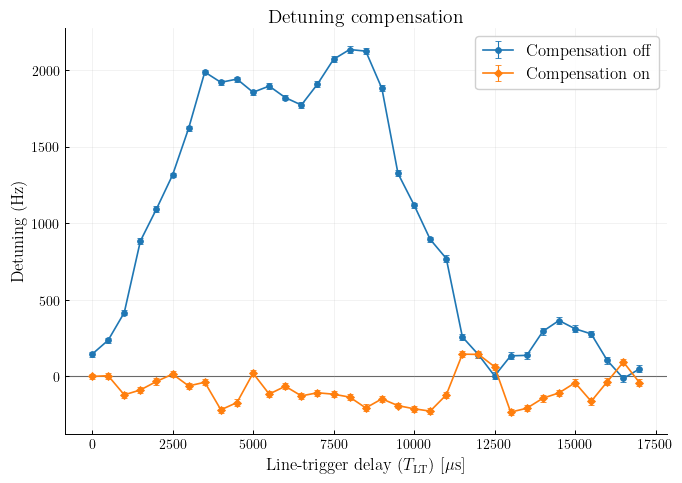

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# =========================================================
# NATURE-STYLE PLOT SETTINGS
# =========================================================
rcParams["font.family"] = "serif"
rcParams["font.serif"] = ["Computer Modern"]
rcParams["text.usetex"] = True
rcParams["figure.figsize"] = (8, 8)

rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 12,

    "axes.linewidth": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,

    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =========================================================
# USER OPTIONS
# =========================================================
LINE_FREQ_HZ = 60.0
HARMONIC_K = 10

# If True, overlay the harmonic fits used for the structured-signal metrics.
SHOW_HARMONIC_FIT_LINES = False

# Template used for correlation:
# "off_fit" means the compensation-off harmonic fit is used as the line-synchronous template.
TEMPLATE_SOURCE = "off_fit"


# =========================================================
# HARMONIC MODEL HELPERS
# =========================================================
def harmonic_design_matrix(t_us, K=10, line_freq_hz=60.0):
    """
    Linear harmonic model:
        y(t) = c0 + sum_n [a_n cos(2 pi n f_line t) + b_n sin(2 pi n f_line t)]

    t_us is in microseconds.
    """
    t_s = np.asarray(t_us, dtype=float) * 1e-6

    columns = [np.ones_like(t_s)]

    for n in range(1, K + 1):
        omega_t = 2.0 * np.pi * n * line_freq_hz * t_s
        columns.append(np.cos(omega_t))
        columns.append(np.sin(omega_t))

    return np.column_stack(columns)


def evaluate_harmonic_model(t_us, params, line_freq_hz=60.0):
    """
    Evaluate harmonic model from linear parameters:
        params = [c0, a1, b1, a2, b2, ...]
    """
    K = (len(params) - 1) // 2
    X = harmonic_design_matrix(t_us, K=K, line_freq_hz=line_freq_hz)
    return X @ params


def fit_harmonic_model(t_us, y_hz, yerr_hz=None, K=10, line_freq_hz=60.0):
    """
    Fit a fixed-frequency harmonic model to the detuning data.

    Returns:
        params: [c0, a1, b1, a2, b2, ...]
        amplitudes: A_n = sqrt(a_n^2 + b_n^2)
        harmonic_amplitude_norm_hz = sqrt(sum A_n^2)
        harmonic_structured_rms_hz = sqrt(1/2 sum A_n^2)
    """
    t_us = np.asarray(t_us, dtype=float)
    y_hz = np.asarray(y_hz, dtype=float)

    valid = np.isfinite(t_us) & np.isfinite(y_hz)

    if yerr_hz is not None:
        yerr_hz = np.asarray(yerr_hz, dtype=float)
        valid &= np.isfinite(yerr_hz) | ~np.isfinite(yerr_hz)

    t_fit = t_us[valid]
    y_fit = y_hz[valid]

    n_points = len(y_fit)
    n_params = 2 * K + 1

    if n_points <= n_params:
        raise ValueError(
            f"Not enough data points for K={K}: "
            f"N={n_points}, parameters={n_params}."
        )

    X = harmonic_design_matrix(t_fit, K=K, line_freq_hz=line_freq_hz)

    # Use weighted least squares only if all uncertainties are finite and positive.
    use_weights = False
    if yerr_hz is not None:
        sigma = np.asarray(yerr_hz, dtype=float)[valid]
        if np.all(np.isfinite(sigma)) and np.all(sigma > 0):
            use_weights = True

    if use_weights:
        Xw = X / sigma[:, None]
        yw = y_fit / sigma
        params, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
    else:
        params, *_ = np.linalg.lstsq(X, y_fit, rcond=None)

    y_model = X @ params
    residual = y_fit - y_model

    a_coeffs = params[1::2]
    b_coeffs = params[2::2]
    amplitudes = np.sqrt(a_coeffs**2 + b_coeffs**2)

    harmonic_amplitude_norm_hz = np.sqrt(np.sum(amplitudes**2))
    harmonic_structured_rms_hz = np.sqrt(0.5 * np.sum(amplitudes**2))

    return {
        "K": K,
        "t_us": t_fit,
        "y_hz": y_fit,
        "params": params,
        "y_model_hz": y_model,
        "residual_hz": residual,
        "amplitudes_hz": amplitudes,
        "harmonic_amplitude_norm_hz": harmonic_amplitude_norm_hz,
        "harmonic_structured_rms_hz": harmonic_structured_rms_hz,
        "offset_hz": params[0],
        "n_points": n_points,
        "n_params": n_params,
        "dof": n_points - n_params,
    }


# =========================================================
# TEMPLATE / CORRELATION HELPERS
# =========================================================
def pearson_correlation(y, template):
    """
    Pearson correlation between y and template after mean subtraction.
    """
    y = np.asarray(y, dtype=float)
    template = np.asarray(template, dtype=float)

    valid = np.isfinite(y) & np.isfinite(template)
    y = y[valid]
    template = template[valid]

    if len(y) < 2:
        return np.nan

    y0 = y - np.mean(y)
    t0 = template - np.mean(template)

    denom = np.sqrt(np.sum(y0**2) * np.sum(t0**2))

    if denom == 0:
        return np.nan

    return np.sum(y0 * t0) / denom


def template_projection(y, template):
    """
    Fit y = b + a * template.

    Returns:
        a: dimensionless template scale
        b: offset
        y_fit: projected template fit
    """
    y = np.asarray(y, dtype=float)
    template = np.asarray(template, dtype=float)

    valid = np.isfinite(y) & np.isfinite(template)
    y_valid = y[valid]
    template_valid = template[valid]

    if len(y_valid) < 2:
        return {
            "scale": np.nan,
            "offset": np.nan,
            "y_fit": np.full_like(y, np.nan),
        }

    X = np.column_stack([np.ones_like(template_valid), template_valid])
    coeffs, *_ = np.linalg.lstsq(X, y_valid, rcond=None)

    offset = coeffs[0]
    scale = coeffs[1]

    y_fit = np.full_like(y, np.nan, dtype=float)
    y_fit[valid] = offset + scale * template_valid

    return {
        "scale": scale,
        "offset": offset,
        "y_fit": y_fit,
    }


def compute_structured_compensation_metrics(data_by_comp):
    """
    Compute:
      1. Harmonic-power suppression.
      2. Correlation with the compensation-off line-synchronous template.
      3. Template projection scale.
    """
    fits_by_comp = {}

    for comp_flag in (False, True):
        data = data_by_comp.get(comp_flag)

        if data is None:
            fits_by_comp[comp_flag] = None
            continue

        fits_by_comp[comp_flag] = fit_harmonic_model(
            data["wait_times_us"],
            data["detunings_hz"],
            yerr_hz=data["detuning_errors_hz"],
            K=HARMONIC_K,
            line_freq_hz=LINE_FREQ_HZ,
        )

    off_fit = fits_by_comp.get(False)
    on_fit = fits_by_comp.get(True)

    if off_fit is None:
        raise ValueError("Need compensation-off data to define the line-synchronous template.")

    metrics_by_comp = {}

    for comp_flag in (False, True):
        data = data_by_comp.get(comp_flag)
        fit = fits_by_comp.get(comp_flag)

        if data is None or fit is None:
            metrics_by_comp[comp_flag] = None
            continue

        # Use the compensation-off harmonic fit as the line-synchronous template.
        if TEMPLATE_SOURCE == "off_fit":
            template_at_data = evaluate_harmonic_model(
                data["wait_times_us"],
                off_fit["params"],
                line_freq_hz=LINE_FREQ_HZ,
            )
        else:
            raise ValueError(f"Unknown TEMPLATE_SOURCE: {TEMPLATE_SOURCE}")

        rho = pearson_correlation(data["detunings_hz"], template_at_data)
        projection = template_projection(data["detunings_hz"], template_at_data)

        metrics_by_comp[comp_flag] = {
            "fit": fit,
            "template_at_data_hz": template_at_data,
            "correlation_with_template": rho,
            "template_scale": projection["scale"],
            "template_offset_hz": projection["offset"],
            "template_projection_fit_hz": projection["y_fit"],
        }

    return metrics_by_comp, fits_by_comp


def print_structured_compensation_summary(metrics_by_comp):
    off = metrics_by_comp.get(False)
    on = metrics_by_comp.get(True)

    print("\n" + "=" * 82)
    print("Structured detuning-compensation summary")
    print("=" * 82)
    print(f"Harmonic basis: first {HARMONIC_K} harmonics of {LINE_FREQ_HZ:.1f} Hz")
    print("Template for correlation/projection: compensation-off harmonic fit")

    for comp_flag, name in [(False, "Compensation OFF"), (True, "Compensation ON")]:
        m = metrics_by_comp.get(comp_flag)

        if m is None:
            print(f"\n{name}: no valid data")
            continue

        fit = m["fit"]
        amplitudes = fit["amplitudes_hz"]

        print(f"\n{name}")
        print(f"  N points                         = {fit['n_points']}")
        print(f"  Harmonic fit parameters          = {fit['n_params']}")
        print(f"  Harmonic fit degrees of freedom  = {fit['dof']}")
        print(f"  Offset from harmonic fit         = {fit['offset_hz']:.3f} Hz")
        print(f"  Harmonic amplitude norm          = {fit['harmonic_amplitude_norm_hz']:.3f} Hz")
        print(f"  Harmonic structured RMS          = {fit['harmonic_structured_rms_hz']:.3f} Hz")
        print(f"  Correlation with LS template     = {m['correlation_with_template']:.4f}")
        print(f"  Template projection scale        = {m['template_scale']:.4f}")
        print(f"  Template projection offset       = {m['template_offset_hz']:.3f} Hz")

        print("  Harmonic amplitudes [Hz]:")
        for i, amp in enumerate(amplitudes, start=1):
            print(f"    n={i:2d}, f={i * LINE_FREQ_HZ:6.1f} Hz: A_n = {amp:.3f} Hz")

    if off is not None and on is not None:
        off_fit = off["fit"]
        on_fit = on["fit"]

        amp_off = off_fit["harmonic_amplitude_norm_hz"]
        amp_on = on_fit["harmonic_amplitude_norm_hz"]

        rms_off = off_fit["harmonic_structured_rms_hz"]
        rms_on = on_fit["harmonic_structured_rms_hz"]

        rho_off = off["correlation_with_template"]
        rho_on = on["correlation_with_template"]

        scale_off = off["template_scale"]
        scale_on = on["template_scale"]

        print("\nSuppression / reduction metrics")

        if amp_on > 0:
            print(f"  Harmonic-power amplitude suppression = {amp_off / amp_on:.2f}x")
            print(f"  Harmonic-power amplitude reduction   = {100 * (1 - amp_on / amp_off):.1f}%")

        if rms_on > 0:
            print(f"  Structured RMS suppression           = {rms_off / rms_on:.2f}x")
            print(f"  Structured RMS reduction             = {100 * (1 - rms_on / rms_off):.1f}%")

        if np.isfinite(rho_off) and np.isfinite(rho_on) and abs(rho_off) > 0:
            print(f"  |Correlation| reduction              = {100 * (1 - abs(rho_on) / abs(rho_off)):.1f}%")
            print(f"  Correlation off -> on                = {rho_off:.4f} -> {rho_on:.4f}")

        if np.isfinite(scale_off) and np.isfinite(scale_on) and abs(scale_on) > 0:
            print(f"  Template-scale suppression           = {abs(scale_off) / abs(scale_on):.2f}x")
            print(f"  Template scale off -> on             = {scale_off:.4f} -> {scale_on:.4f}")

    print("=" * 82 + "\n")


# =========================================================
# DATA EXTRACTION
# =========================================================
def extract_detuning_data_by_comp(detuning_fit_results_by_comp):
    """
    Convert detuning_fit_results_by_comp into sorted arrays in Hz.
    """
    data_by_comp = {}

    for comp_flag in (False, True):
        result = detuning_fit_results_by_comp.get(comp_flag, {})

        wait_times = np.array(result.get("fit_wait_times_list", []), dtype=float)

        detunings = np.array(
            [np.nan if d is None else d for d in result.get("fit_detunings_list", [])],
            dtype=float,
        )

        detuning_errors = np.array(
            [np.nan if e is None else e for e in result.get("fit_detuning_errors_list", [])],
            dtype=float,
        )

        valid = np.isfinite(wait_times) & np.isfinite(detunings)

        if not np.any(valid):
            print(f"Comp {comp_flag}: no finite detuning points.")
            data_by_comp[comp_flag] = None
            continue

        wait_times = wait_times[valid]
        detunings_hz = detunings[valid] / (2 * np.pi)
        detuning_errors_hz = detuning_errors[valid] / (2 * np.pi)

        order = np.argsort(wait_times)

        data_by_comp[comp_flag] = {
            "wait_times_us": wait_times[order],
            "detunings_hz": detunings_hz[order],
            "detuning_errors_hz": detuning_errors_hz[order],
        }

    return data_by_comp


# =========================================================
# PLOT
# =========================================================
def plot_detuning_comparison_by_comp(detuning_fit_results_by_comp):
    fig, ax = plt.subplots(figsize=(7, 5))

    colors = {
        False: "C0",
        True: "C1",
    }

    labels = {
        False: "Compensation off",
        True: "Compensation on",
    }

    markers = {
        False: "o",
        True: "D",
    }

    data_by_comp = extract_detuning_data_by_comp(detuning_fit_results_by_comp)

    plotted_any = False

    for comp_flag in (False, True):
        data = data_by_comp.get(comp_flag)

        if data is None:
            continue

        wait_times = data["wait_times_us"]
        detunings_hz = data["detunings_hz"]
        detuning_errors_hz = data["detuning_errors_hz"]

        yerr = np.where(np.isfinite(detuning_errors_hz), detuning_errors_hz, 0.0)

        ax.errorbar(
            wait_times,
            detunings_hz,
            yerr=yerr,
            fmt=markers[comp_flag],
            markersize=4.2,
            linestyle="-",
            linewidth=1.2,
            capsize=2.5,
            elinewidth=0.8,
            markeredgewidth=0.6,
            color=colors[comp_flag],
            ecolor=colors[comp_flag],
            label=labels[comp_flag],
            zorder=3,
        )

        plotted_any = True

    if not plotted_any:
        return None

    metrics_by_comp, fits_by_comp = compute_structured_compensation_metrics(data_by_comp)

    print_structured_compensation_summary(metrics_by_comp)

    if SHOW_HARMONIC_FIT_LINES:
        for comp_flag in (False, True):
            data = data_by_comp.get(comp_flag)
            fit = fits_by_comp.get(comp_flag)

            if data is None or fit is None:
                continue

            t_fit_us = np.linspace(
                np.min(data["wait_times_us"]),
                np.max(data["wait_times_us"]),
                1500,
            )

            y_fit_hz = evaluate_harmonic_model(
                t_fit_us,
                fit["params"],
                line_freq_hz=LINE_FREQ_HZ,
            )

            ax.plot(
                t_fit_us,
                y_fit_hz,
                color=colors[comp_flag],
                linewidth=1.4,
                alpha=0.85,
                zorder=2,
            )

    ax.axhline(
        0.0,
        color="0.2",
        linewidth=0.8,
        alpha=0.8,
        zorder=1,
    )

    ax.set_xlabel(r"Line-trigger delay ($T_{\mathrm{LT}}$) [$\mu$s]")
    ax.set_ylabel("Detuning (Hz)")
    ax.set_title("Detuning compensation", pad=4)

    ax.grid(True, which="major", linewidth=0.45, alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="best",
        frameon=True,
        framealpha=0.92,
        borderpad=0.45,
        handlelength=1.8,
    )

    fig.tight_layout()

    fig.savefig("detuning_compensation_nature_style.svg", bbox_inches="tight")
    fig.savefig("detuning_compensation_nature_style.pdf", bbox_inches="tight")
    fig.savefig("detuning_compensation_nature_style.png", dpi=600, bbox_inches="tight")

    plt.show()

    return ax, metrics_by_comp, fits_by_comp


ax, detuning_structured_metrics_by_comp, detuning_harmonic_fits_by_comp = (
    plot_detuning_comparison_by_comp(detuning_fit_results_by_comp)
)

# Fitter

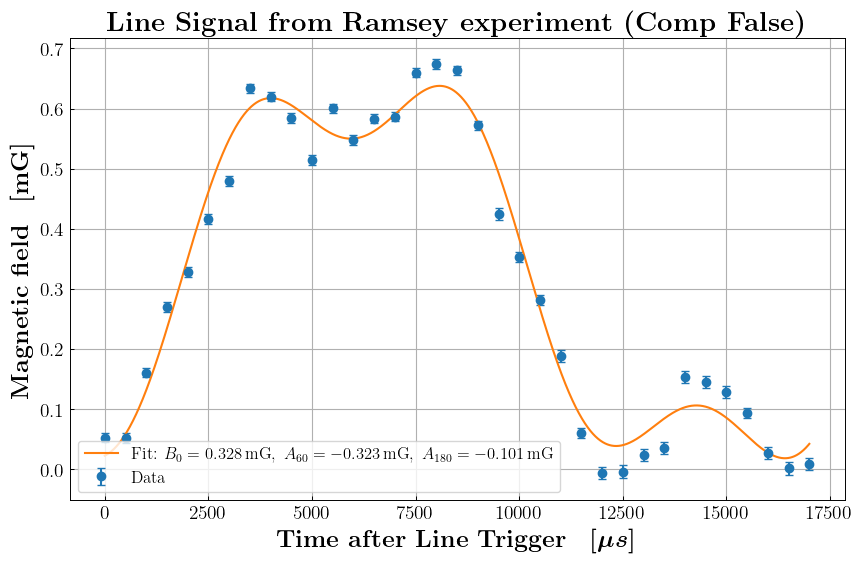

Fitted line-synchronous field (mG):
  B0      = 0.3281 ± 0.0015 mG
  A_60    = -0.3230 ± 0.0021 mG
  phi_60  = 0.8314 ± 0.0063 rad
  A_180   = -0.1006 ± 0.0020 mG
  phi_180 = -0.5112 ± 0.0208 rad


In [66]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True

line_signal_comp_flag = False
line_signal_detuning_result = detuning_fit_results_by_comp[line_signal_comp_flag]

fit_wait_times_array = np.array(line_signal_detuning_result["fit_wait_times_list"], dtype=float)
fit_detunings_array = np.array(
    [np.nan if d is None else d for d in line_signal_detuning_result["fit_detunings_list"]],
    dtype=float,
)
fit_detuning_errors_array = np.array(
    [np.nan if e is None else e for e in line_signal_detuning_result["fit_detuning_errors_list"]],
    dtype=float,
)

B_array = (fit_detunings_array / 3.2e3) / (2 * np.pi)
B_err_array = np.abs(fit_detuning_errors_array / 3.2e3 / (2 * np.pi))

mask = np.isfinite(fit_wait_times_array) & np.isfinite(B_array) & np.isfinite(B_err_array)
t_us = fit_wait_times_array[mask]
B = B_array[mask]
B_err = B_err_array[mask]

def line_signal_model(t_us, B0, A60, phi60, A180, phi180):
    t_s = t_us * 1e-6
    return (
        B0
        + A60 * np.cos(2 * np.pi * 60 * t_s + phi60)
        + A180 * np.cos(2 * np.pi * 180 * t_s + phi180)
    )

B0_0 = np.mean(B)
A_guess = 0.5 * (np.max(B) - np.min(B))
p0 = [B0_0, A_guess, 0.0, 0.3 * A_guess, 0.0]

params, covariance = curve_fit(
    line_signal_model,
    t_us,
    B,
    p0=p0,
    sigma=B_err,
    absolute_sigma=True,
    maxfev=20000
)

B0_fit, A60_fit, phi60_fit, A180_fit, phi180_fit = params
if covariance is not None:
    perr = np.sqrt(np.diag(covariance))
else:
    perr = [np.nan] * len(params)
B0_err, A60_err, phi60_err, A180_err, phi180_err = perr

t_fine_us = np.linspace(t_us.min(), t_us.max(), 2000)
B_fit_curve = line_signal_model(t_fine_us, *params)

plt.figure(figsize=(10, 6))
plt.errorbar(
    fit_wait_times_array,
    B_array,
    yerr=B_err_array,
    fmt='o',
    capsize=3,
    label=r'Data'
)
plt.plot(
    t_fine_us,
    B_fit_curve,
    label=(
        r'Fit: $B_0={:.3f}\,\mathrm{{mG}},\ A_{{60}}={:.3f}\,\mathrm{{mG}},\ '
        r'A_{{180}}={:.3f}\,\mathrm{{mG}}$'
    ).format(B0_fit, A60_fit, A180_fit)
)

plt.xlabel(r'\boldmath$\textbf{Time after Line Trigger}\quad [\mu s]$', fontsize=18)
plt.ylabel(r'\boldmath$\textbf{Magnetic field}\quad [\mathrm{mG}]$', fontsize=18)
plt.title(r'\textbf{Line Signal from Ramsey experiment (Comp False)}', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid()
plt.legend(fontsize=12)
plt.savefig('line_signal_fit_60_180Hz_comp_false.png', dpi=300, bbox_inches="tight")
plt.show()

print("Fitted line-synchronous field (mG):")
print("  B0      = {:.4f} ± {:.4f} mG".format(B0_fit, B0_err))
print("  A_60    = {:.4f} ± {:.4f} mG".format(A60_fit, A60_err))
print("  phi_60  = {:.4f} ± {:.4f} rad".format(phi60_fit, phi60_err))
print("  A_180   = {:.4f} ± {:.4f} mG".format(A180_fit, A180_err))
print("  phi_180 = {:.4f} ± {:.4f} rad".format(phi180_fit, phi180_err))


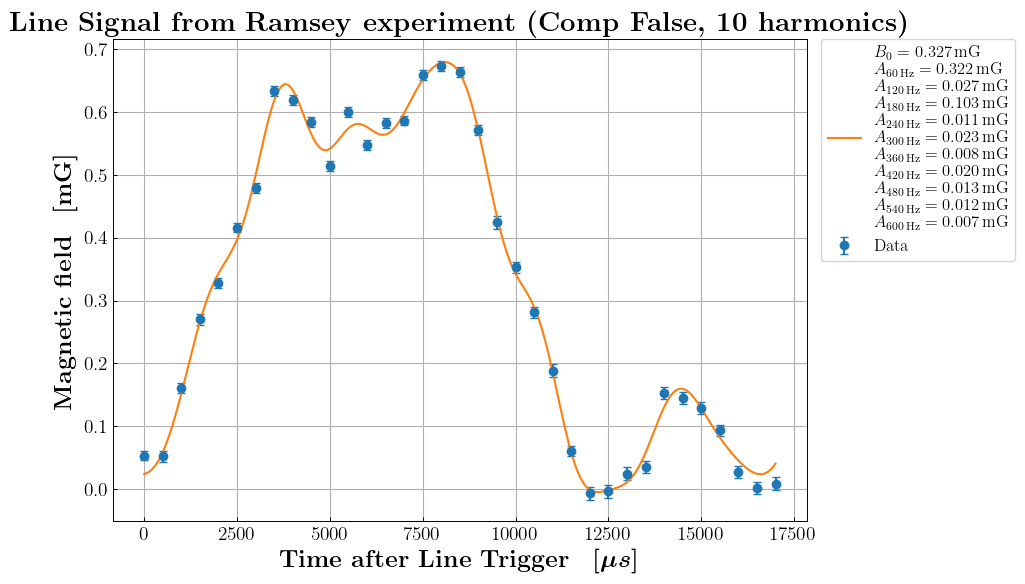

Fitted line-synchronous field (mG):
  B0      = 0.3271 ± 0.0015 mG
  A_ 60   = 0.3218 ± 0.0021 mG
  phi_ 60 = -2.2977 ± 0.0064 rad
  A_120   = 0.0270 ± 0.0021 mG
  phi_120 = 0.6952 ± 0.0786 rad
  A_180   = 0.1027 ± 0.0021 mG
  phi_180 = 2.6030 ± 0.0208 rad
  A_240   = 0.0109 ± 0.0021 mG
  phi_240 = 2.4342 ± 0.1943 rad
  A_300   = 0.0229 ± 0.0021 mG
  phi_300 = -2.0763 ± 0.0899 rad
  A_360   = 0.0081 ± 0.0021 mG
  phi_360 = -0.9218 ± 0.2634 rad
  A_420   = 0.0205 ± 0.0021 mG
  phi_420 = 2.9784 ± 0.1024 rad
  A_480   = 0.0134 ± 0.0021 mG
  phi_480 = 0.8716 ± 0.1550 rad
  A_540   = 0.0116 ± 0.0021 mG
  phi_540 = 0.7755 ± 0.1813 rad
  A_600   = 0.0070 ± 0.0021 mG
  phi_600 = -2.2221 ± 0.2983 rad


: 

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True

line_signal_comp_flag = False
line_signal_detuning_result = detuning_fit_results_by_comp[line_signal_comp_flag]

fit_wait_times_array = np.array(line_signal_detuning_result["fit_wait_times_list"], dtype=float)
fit_detunings_array = np.array(
    [np.nan if d is None else d for d in line_signal_detuning_result["fit_detunings_list"]],
    dtype=float,
)
fit_detuning_errors_array = np.array(
    [np.nan if e is None else e for e in line_signal_detuning_result["fit_detuning_errors_list"]],
    dtype=float,
)

B_array = (fit_detunings_array / (3.20153e3)) / (2 * np.pi)
B_err_array = np.abs(fit_detuning_errors_array / 3.20153e3 / (2 * np.pi))

mask = np.isfinite(fit_wait_times_array) & np.isfinite(B_array) & np.isfinite(B_err_array)
t_us = fit_wait_times_array[mask]
B = B_array[mask]
B_err = B_err_array[mask]

fit_freqs = [60, 120, 180, 240, 300, 360, 420, 480, 540, 600]

def line_signal_model(t_us, *params):
    t_s = t_us * 1e-6
    B0 = params[0]
    y = B0
    for i, f in enumerate(fit_freqs):
        A = params[1 + 2 * i]
        phi = params[1 + 2 * i + 1]
        y = y + A * np.cos(2 * np.pi * f * t_s + phi)
    return y

B0_0 = np.mean(B)
A_guess = 0.5 * (np.max(B) - np.min(B))
p0 = [B0_0]
for i, f in enumerate(fit_freqs):
    if i == 0:
        A0 = A_guess
    else:
        A0 = 0.3 * A_guess
    p0.extend([A0, 0.0])

lower_bounds = [-np.inf]
upper_bounds = [np.inf]

for i in range(len(fit_freqs)):
    lower_bounds.extend([0.0, -np.inf])
    upper_bounds.extend([np.inf, np.inf])

params, covariance = curve_fit(
    line_signal_model,
    t_us,
    B,
    p0=p0,
    sigma=B_err,
    absolute_sigma=True,
    maxfev=20000,
    bounds=(lower_bounds, upper_bounds)
)

if covariance is not None:
    perr = np.sqrt(np.diag(covariance))
else:
    perr = [np.nan] * len(params)

B0_fit = params[0]
B0_err = perr[0]

harmonic_results = []
for i, f in enumerate(fit_freqs):
    A = params[1 + 2 * i]
    phi = params[1 + 2 * i + 1]
    A_err = perr[1 + 2 * i]
    phi_err = perr[1 + 2 * i + 1]
    harmonic_results.append((f, A, A_err, phi, phi_err))

t_fine_us = np.linspace(t_us.min(), t_us.max(), 2000)
B_fit_curve = line_signal_model(t_fine_us, *params)

legend_lines = [r'$B_0={:.3f}\,\mathrm{{mG}}$'.format(B0_fit)]
for f, A, A_err, phi, phi_err in harmonic_results:
    legend_lines.append(r'$A_{{{:g}\,\mathrm{{Hz}}}}={:.3f}\,\mathrm{{mG}}$'.format(f, A))
fit_label = '\n'.join(legend_lines)

plt.figure(figsize=(10, 6))
plt.errorbar(
    fit_wait_times_array,
    B_array,
    yerr=B_err_array,
    fmt='o',
    capsize=3,
    label=r'Data'
)
plt.plot(
    t_fine_us,
    B_fit_curve,
    label=fit_label
)

plt.xlabel(r'\boldmath$\textbf{Time after Line Trigger}\quad [\mu s]$', fontsize=18)
plt.ylabel(r'\boldmath$\textbf{Magnetic field}\quad [\mathrm{mG}]$', fontsize=18)
plt.title(r'\textbf{Line Signal from Ramsey experiment (Comp False, 10 harmonics)}', fontsize=20)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid()

plt.legend(
    fontsize=12,
    loc='upper left',
    bbox_to_anchor=(1.02, 1.0),
    borderaxespad=0.0
)

plt.tight_layout()
plt.savefig('line_signal_fit_10_harmonics_comp_false.png', dpi=300, bbox_inches="tight")
plt.show()

print("Fitted line-synchronous field (mG):")
print("  B0      = {:.4f} ± {:.4f} mG".format(B0_fit, B0_err))
for f, A, A_err, phi, phi_err in harmonic_results:
    print("  A_{:3.0f}   = {:.4f} ± {:.4f} mG".format(f, A, A_err))
    print("  phi_{:3.0f} = {:.4f} ± {:.4f} rad".format(f, phi, phi_err))


def save_fit_parameters(filename, B0_fit, B0_err, harmonic_results):
    with open(filename, "w") as f:
        f.write("# B0 B0_err (mG)\n")
        f.write("{:.18e} {:.18e}\n".format(B0_fit, B0_err))
        f.write("# f_Hz A A_err phi phi_err\n")
        for f_hz, A, A_err, phi, phi_err in harmonic_results:
            f.write(
                "{:10.3f} {:.18e} {:.18e} {:.18e} {:.18e}\n".format(
                    f_hz, A, A_err, phi, phi_err
                )
            )

save_fit_parameters("line_signal_fit_params_comp_false_10harmonics.txt", B0_fit, B0_err, harmonic_results)
